In [ ]:
!pip install pyxlsb

In [ ]:
import zipfile
import os
import pandas as pd

# --- Step 1: Upload and unzip ---
from google.colab import files
uploaded = files.upload()   # Upload 2025-Data.zip

zip_path = "2025-Data.zip"
extract_path = "/content/2025-Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped to:", extract_path)

Saving 2025-Data.zip to 2025-Data.zip
Saving CIEP_cleaned.csv to CIEP_cleaned.csv
Saving GPC_cleaned.csv to GPC_cleaned.csv
Saving GPI_cleaned.csv to GPI_cleaned.csv
Saving GSC_cleaned.csv to GSC_cleaned.csv
Saving GSI_cleaned.csv to GSI_cleaned.csv
Saving GSTC_cleaned.csv to GSTC_cleaned.csv
Saving GSTI_cleaned.csv to GSTI_cleaned.csv
Saving GTC_cleaned.csv to GTC_cleaned.csv
Saving GTI_cleaned.csv to GTI_cleaned.csv
Saving Res_cleaned.csv to Res_cleaned.csv
Saving RSCP_cleaned.csv to RSCP_cleaned.csv
Unzipped to: /content/2025-Data


# Inspecting Dataset

- The dataset consists of multiple sources (Predict-Y for load data and Predict With-X for explanatory features like weather, economic, and energy data).
- Many files have extra header rows (metadata, units, “Update” notes) before actual data begins (e.g., RSCP and CIEP hourly load files).
- Some columns are marked as Unnamed, which suggests misaligned headers during import. 🅰️
- Date/time formats are inconsistent across files:
- Some in MM/DD/YYYY
- Some in YYYY-MM-DD HH:MM AM/PM
- Some quarterly (2022:Q1) or yearly (1998, 2020).
- Missing values (NaN) appear frequently in hourly load and weather data.
- Weather files include values with units (42F, 8mph, 30.00in) that must be converted to numeric.
- Energy and economic datasets are longitudinal tables (wide format) and will need to be reshaped into long format for easier merging.


🅰️ When inspecting dataset..... "We get a lot of "Unnamed" columns. Need to fix with data cleaning and then run this data inspection again.

In [ ]:
# --- Step 2: Explore all subfolders and files ---
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


# --- Step 3: Try loading tabular files ---
def preview_file(filepath):
    try:
        if filepath.endswith(".csv"):
            df = pd.read_csv(filepath)
        elif filepath.endswith(".xlsx"):
            df = pd.read_excel(filepath)
        elif filepath.endswith(".txt"):
            with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
                print(f.read()[:500])  # print first 500 chars
            return
        else:
            return

        print(f"\n Preview of {filepath}:")
        print(df.head())
        print("-" * 80)
    except Exception as e:
        print(f"Could not load {filepath}: {e}")


# Walk again and preview tabular files
for root, dirs, files in os.walk(extract_path):
    for f in files:
        filepath = os.path.join(root, f)
        preview_file(filepath)


2025-Data/
    Data/
        ! Read Me.txt
        Predict With - X/
            Date_Catagories.xlsx
            ! Read Me.txt
            Economic/
                ! Read Me.txt
                Annual personal income and employment/
                    SAINC5N__Footnotes.html
                    SAINC5N_NJ_1998_2023.csv
                    SAINC6N__Footnotes.html
                    SAINC6N_NJ_1998_2023.csv
                    SAINC7N__Footnotes.html
                    SAINC7N_NJ_1998_2023.csv
                    SAINC4_NJ_1929_2023.csv
                    SAINC4__Footnotes.html
                Personal consumption expenditures/
                    SAPCE3_NJ_1997_2022.csv
                    SAPCE2_NJ_1997_2022.csv
                    SAPCE1_NJ_1997_2022.csv
                    SAPCE2__Footnotes.html
                    SAPCE4__Footnotes.html
                    SAPCE1__Footnotes.html
                    SAPCE4_NJ_1997_2022.csv
                    SAPCE3__Footnotes.html
            

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



 Preview of /content/2025-Data/Data/Predict With - X/Economic/Employment/SeriesReport-20240905203255_d72ca2.xlsx:
  Local Area Unemployment Statistics            Unnamed: 1 Unnamed: 2  \
0                Original Data Value                   NaN        NaN   
1                                NaN                   NaN        NaN   
2                         Series Id:  LASST340000000000005        NaN   
3                Seasonally Adjusted                   NaN        NaN   
4                              Area:            New Jersey        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3        NaN        NaN        NaN        NaN        NaN        NaN   
4        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9 Unname

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



 Preview of /content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2019.csv:
                 Time Temperature Dew Point Humidity  Wind Wind Speed  \
0  2019-01-01 1:51 AM         46F       46F     100%  CALM       0mph   
1  2019-01-01 2:51 AM         47F       46F      97%  CALM       0mph   
2  2019-01-01 3:45 AM         46F       46F     100%    SW       3mph   
3  2019-01-01 3:51 AM         47F       47F     100%   WSW       5mph   
4  2019-01-01 4:15 AM         47F       47F     100%     W       6mph   

  Wind Gust Pressure Precipitation   Condition  
0      0mph  29.73in         0.1in  Light Rain  
1      0mph  29.67in         0.0in  Light Rain  
2      0mph  29.62in         0.0in         Fog  
3      0mph  29.62in         0.0in         Fog  
4      0mph  29.63in         0.0in  Light Rain  
--------------------------------------------------------------------------------

 Preview of /content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_n

In [ ]:
import os
import pandas as pd

base_path = "/content/2025-Data"   # after unzipping

# Function to safely read csv/xlsx and print columns
def show_columns(filepath):
    try:
        if filepath.endswith(".csv"):
            df = pd.read_csv(filepath, nrows=5)   # read just first 5 rows
        elif filepath.endswith(".xlsx"):
            df = pd.read_excel(filepath, nrows=5)
        else:
            return

        print(f"\n {filepath}")
        print("|| Columns:", list(df.columns))
        print("-" * 80)
    except Exception as e:
        print(f"⚠️ Could not load {filepath}: {e}")

# Walk through all subfolders and check each file
for root, dirs, files in os.walk(base_path):
    for f in files:
        filepath = os.path.join(root, f)
        if f.endswith((".csv", ".xlsx")):
            show_columns(filepath)


 /content/2025-Data/Data/Predict With - X/Date_Catagories.xlsx
|| Columns: ['Date', 'Weekday', 'Weekend', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'Holiday']
--------------------------------------------------------------------------------

 /content/2025-Data/Data/Predict With - X/Economic/Annual personal income and employment/SAINC5N_NJ_1998_2023.csv
|| Columns: ['GeoFIPS', 'GeoName', 'Region', 'TableName', 'LineCode', 'IndustryClassification', 'Description', 'Unit', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
--------------------------------------------------------------------------------

 /content/2025-Data/Data/Predict With - X/Economic/Annual personal income and employment/SAINC6N_NJ_1998_2023.csv
|| Columns: ['GeoFIPS', 'GeoName', 'Regio

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



 /content/2025-Data/Data/Predict With - X/Economic/Quarterly personal income/SQINC4_NJ_1948_2024.csv
|| Columns: ['GeoFIPS', 'GeoName', 'Region', 'TableName', 'LineCode', 'IndustryClassification', 'Description', 'Unit', '1948:Q1', '1948:Q2', '1948:Q3', '1948:Q4', '1949:Q1', '1949:Q2', '1949:Q3', '1949:Q4', '1950:Q1', '1950:Q2', '1950:Q3', '1950:Q4', '1951:Q1', '1951:Q2', '1951:Q3', '1951:Q4', '1952:Q1', '1952:Q2', '1952:Q3', '1952:Q4', '1953:Q1', '1953:Q2', '1953:Q3', '1953:Q4', '1954:Q1', '1954:Q2', '1954:Q3', '1954:Q4', '1955:Q1', '1955:Q2', '1955:Q3', '1955:Q4', '1956:Q1', '1956:Q2', '1956:Q3', '1956:Q4', '1957:Q1', '1957:Q2', '1957:Q3', '1957:Q4', '1958:Q1', '1958:Q2', '1958:Q3', '1958:Q4', '1959:Q1', '1959:Q2', '1959:Q3', '1959:Q4', '1960:Q1', '1960:Q2', '1960:Q3', '1960:Q4', '1961:Q1', '1961:Q2', '1961:Q3', '1961:Q4', '1962:Q1', '1962:Q2', '1962:Q3', '1962:Q4', '1963:Q1', '1963:Q2', '1963:Q3', '1963:Q4', '1964:Q1', '1964:Q2', '1964:Q3', '1964:Q4', '1965:Q1', '1965:Q2', '1965:Q3'

In [ ]:
import os
import pandas as pd

base_path = "/content/2025-Data"   # after unzipping

# Function to classify variables
def classify_columns(df):
    col_info = {}
    for col in df.columns:
        dtype = df[col].dtype

        if pd.api.types.is_numeric_dtype(dtype):
            col_info[col] = "Quantitative"
        elif pd.api.types.is_datetime64_any_dtype(dtype):
            col_info[col] = "Datetime"
        else:
            # Heuristic: low unique count relative to rows -> categorical
            unique_vals = df[col].nunique(dropna=True)
            if unique_vals < 50:
                col_info[col] = "Categorical"
            else:
                col_info[col] = "Textual--- this is metadata."
    return col_info


# Function to show details for each file
def analyze_file(filepath):
    try:
        if filepath.endswith(".csv"):
            df = pd.read_csv(filepath)
        elif filepath.endswith(".xlsx"):
            df = pd.read_excel(filepath)
        else:
            return

        print(f"\n {filepath}")
        print(f"|| Rows: {len(df)}, Columns: {len(df.columns)}")

        # Column classifications
        col_types = classify_columns(df)

        # Missing values per column
        missing_counts = df.isna().sum()

        for col, coltype in col_types.items():
            print(f" ! {col}: {coltype}, Missing = {missing_counts[col]}")

        # Total rows with at least 1 missing value
        total_na_rows = df.isna().any(axis=1).sum()
        print(f">>> Total rows with missing values: {total_na_rows}")
        print("-" * 80)

    except Exception as e:
        print(f"Could not load {filepath}: {e}")


# Walk through all subfolders and analyze CSV/XLSX files
for root, dirs, files in os.walk(base_path):
    for f in files:
        filepath = os.path.join(root, f)
        if f.endswith((".csv", ".xlsx")):
            analyze_file(filepath)


 /content/2025-Data/Data/Predict With - X/Date_Catagories.xlsx
|| Rows: 2071, Columns: 16
 ! Date: Textual--- this is metadata., Missing = 0
 ! Weekday: Quantitative, Missing = 0
 ! Weekend: Quantitative, Missing = 0
 ! January: Quantitative, Missing = 0
 ! February: Quantitative, Missing = 0
 ! March: Quantitative, Missing = 0
 ! April: Quantitative, Missing = 0
 ! May: Quantitative, Missing = 0
 ! June: Quantitative, Missing = 0
 ! July: Quantitative, Missing = 0
 ! August: Quantitative, Missing = 0
 ! September: Quantitative, Missing = 0
 ! October: Quantitative, Missing = 0
 ! November: Quantitative, Missing = 0
 ! December: Quantitative, Missing = 0
 ! Holiday: Quantitative, Missing = 0
>>> Total rows with missing values: 0
--------------------------------------------------------------------------------

 /content/2025-Data/Data/Predict With - X/Economic/Annual personal income and employment/SAINC5N_NJ_1998_2023.csv
|| Rows: 135, Columns: 34
 ! GeoFIPS: Categorical, Missing = 0
 

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



 /content/2025-Data/Data/Predict With - X/Economic/Employment/SeriesReport-20240905203255_d72ca2.xlsx
|| Rows: 21, Columns: 13
 ! Local Area Unemployment Statistics: Categorical, Missing = 2
 ! Unnamed: 1: Categorical, Missing = 4
 ! Unnamed: 2: Categorical, Missing = 9
 ! Unnamed: 3: Categorical, Missing = 9
 ! Unnamed: 4: Categorical, Missing = 9
 ! Unnamed: 5: Categorical, Missing = 9
 ! Unnamed: 6: Categorical, Missing = 9
 ! Unnamed: 7: Categorical, Missing = 9
 ! Unnamed: 8: Categorical, Missing = 10
 ! Unnamed: 9: Categorical, Missing = 10
 ! Unnamed: 10: Categorical, Missing = 10
 ! Unnamed: 11: Categorical, Missing = 10
 ! Unnamed: 12: Categorical, Missing = 10
>>> Total rows with missing values: 10
--------------------------------------------------------------------------------

 /content/2025-Data/Data/Predict With - X/Economic/Quarterly personal income/SQINC4_NJ_1948_2024.csv
|| Rows: 24, Columns: 313
 ! GeoFIPS: Categorical, Missing = 0
 ! GeoName: Categorical, Missing = 

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



 /content/2025-Data/Data/Predict With - X/Economic/CPI/SeriesReport-20240905203524_e01037.xlsx
|| Rows: 22, Columns: 15
 ! Consumer Price Index for All Urban Consumers (CPI-U): Categorical, Missing = 2
 ! Unnamed: 1: Categorical, Missing = 4
 ! Unnamed: 2: Categorical, Missing = 10
 ! Unnamed: 3: Categorical, Missing = 10
 ! Unnamed: 4: Categorical, Missing = 10
 ! Unnamed: 5: Categorical, Missing = 10
 ! Unnamed: 6: Categorical, Missing = 10
 ! Unnamed: 7: Categorical, Missing = 10
 ! Unnamed: 8: Categorical, Missing = 11
 ! Unnamed: 9: Categorical, Missing = 11
 ! Unnamed: 10: Categorical, Missing = 11
 ! Unnamed: 11: Categorical, Missing = 11
 ! Unnamed: 12: Categorical, Missing = 11
 ! Unnamed: 13: Categorical, Missing = 21
 ! Unnamed: 14: Categorical, Missing = 21
>>> Total rows with missing values: 21
--------------------------------------------------------------------------------

 /content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2020.csv
|| Rows: 1

# What is the scope of this project?

- Defining what data and how we use it will help with data cleaning as we just remove the rest of the data.

- What years/ months are we looking at and why?

> Answer this.



# Dataset Cleaning

1. Standardize headers.
- Remove metadata rows.
- Rename Unnamed: columns properly (e.g., Hour 1, Hour 2, … → 1, 2, …).

> ❔ Current method is only able to fix 1 dataset at a time. How to improve/ automatically detect metadata row in the dataset and various subfolders.



2. Unify date formats
- Convert all dates/times into a standard datetime index.
- Handle Daylight Savings Time carefully (as discussed).

3. Reshape datasets
- Pivot/reshape hourly load and weather into long format:

      Date | Hour | Load

      Date | Hour | Temp | Humidity | WindSpeed ...

- Reshape economic/energy data from wide to long by year/quarter.

4. Handle units
- Convert Fahrenheit → Celsius (or keep Fahrenheit, but numeric only).
- Convert mph, inches, % into pure numeric.
- Ensure all load units are in MW.

5. Missing values

- Interpolate or forward-fill for continuous time series (load/weather).
- Drop or impute missing values in economic data.

6. Merge datasets

- Join on Date (and Hour where available).
- Create a consistent time-series frame with all explanatory variables aligned.

7. Download Clean Dataset and use it for EDA.

## Predict-Y data cleaning

Cleaned data provided by Daniel Walker in : 2025-Data.zip\2025-Data\Data\cleaned rate class data

In [ ]:
import pandas as pd
import os

base_path = "2025-Data/Data/Predict - y/JCPL"

def standard_header(file_path):
    """
    Cleans a dataset by:
    - Detecting the correct header row (first occurrence of 'Hour 1' or similar).
    - Removing 'Unnamed' columns.
    - Renaming columns consistently.
    - Dropping all-NA rows/cols.
    - Handling Hour25 if present.
    """
    try:
        # Decide read method based on extension
        if file_path.endswith(".csv"):
            raw = pd.read_csv(file_path, header=None)
        elif file_path.endswith((".xls", ".xlsx")):
            raw = pd.read_excel(file_path, header=None, engine="openpyxl" if file_path.endswith("x") else None)
        else:
            print(f"Skipping unsupported file: {file_path}")
            return None

        # Find row index where real header starts (contains "Hour 1" or similar)
        header_row = None
        for i, row in raw.iterrows():
            if row.astype(str).str.contains("Hour 1", case=False, na=False).any():
                header_row = i
                break
        if header_row is None:
            header_row = 0  # fallback

        # Re-read with proper header
        if file_path.endswith(".csv"):
            df = pd.read_csv(file_path, skiprows=header_row)
        else:
            df = pd.read_excel(file_path, skiprows=header_row)

        # Rename first column as Date
        df.rename(columns={df.columns[0]: "Date"}, inplace=True)

        # Drop completely empty rows and columns
        df.dropna(axis=0, how="all", inplace=True)
        df.dropna(axis=1, how="all", inplace=True)

        # Drop columns with "Unnamed"
        df = df.loc[:, ~df.columns.astype(str).str.contains("Unnamed")]

        # Standardize col names
        df.columns = [c.strip().replace(" ", "_") for c in df.columns]

        # Drop Hour25 if present
        if "Hour_25" in df.columns:
            df.drop("Hour_25", axis=1, inplace=True)


        return df

    except Exception as e:
        print(f"Error cleaning {file_path}: {e}")
        return None

def clean_xlsb_hourly(file_path):
    """
    Cleans JCP&L Historical Hourly Load by Class .xlsb files.
    Each sheet = one rate class.
    Returns dict of {sheet_name: cleaned_dataframe}.
    """
    dfs = {}
    xls = pd.ExcelFile(file_path, engine="pyxlsb")

    for sheet in xls.sheet_names:
        df_raw = pd.read_excel(file_path, sheet_name=sheet, engine="pyxlsb", header=None)

        # Find header row (contains 'Hour 1')
        header_row = None
        for i, row in df_raw.iterrows():
            if row.astype(str).str.contains("Hour 1", case=False, na=False).any():
                header_row = i
                break
        if header_row is None:
            continue  # skip if no valid data

        # Re-read with correct header
        df = pd.read_excel(file_path, sheet_name=sheet, engine="pyxlsb", skiprows=header_row)

        # Rename first col as Date
        df.rename(columns={df.columns[0]: "Date"}, inplace=True)

        # Drop empties + Unnamed
        df.dropna(axis=0, how="all", inplace=True)
        df.dropna(axis=1, how="all", inplace=True)
        df = df.loc[:, ~df.columns.astype(str).str.contains("Unnamed")]

        # Standardize col names
        df.columns = [c.strip().replace(" ", "_") for c in df.columns]

        # Drop Hour25 if present
        if "Hour_25" in df.columns:
            df.drop("Hour_25", axis=1, inplace=True)

        dfs[sheet] = df
        print(f"Cleaned {sheet} from {file_path} | Shape: {df.shape}")

    return dfs


def clean_all_datasets(base_path):
    cleaned_data = {}

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith((".csv", ".xlsx", ".xls", ".xlsb")):
                file_path = os.path.join(root, file)
                df = standard_header(file_path)
                if df is not None:
                    cleaned_data[file_path] = df
                    print(f"Cleaned: {file_path} | Shape: {df.shape}")
    return cleaned_data


# Run cleaning on all datasets
all_cleaned = clean_all_datasets(base_path)

# Example: show one cleaned dataset
sample_key = list(all_cleaned.keys())[0]
print(f"\nSample cleaned dataset from {sample_key}:\n")
print(all_cleaned[sample_key].head())


xlsb_path = "/content/2025-Data/Data/Predict - y/JCPL/JCP&L_Historical_Hourly_Load_by_Class_Jun20-May23.xlsb"
xlsb_path0 = "/content/2025-Data/Data/Predict - y/JCPL/JCP&L_Historical_Hourly_Load_by_Class_Jun21-May24.xlsb"
xls1 = pd.ExcelFile(xlsb_path, engine="pyxlsb")
xls2 = pd.ExcelFile(xlsb_path0, engine="pyxlsb")
print("Jun20-May23:", xls1.sheet_names)
print("Jun21-May24:", xls2.sheet_names)


Skipping unsupported file: 2025-Data/Data/Predict - y/JCPL/JCP&L_Historical_Hourly_Load_by_Class_Jun21-May24.xlsb
Skipping unsupported file: 2025-Data/Data/Predict - y/JCPL/JCP&L_Historical_Hourly_Load_by_Class_Jun20-May23.xlsb
Cleaned: 2025-Data/Data/Predict - y/JCPL/CIEP/JCP&L_CIEP-Eligible_Hourly_Load_August_2025_Update.xlsx | Shape: (1096, 25)
Cleaned: 2025-Data/Data/Predict - y/JCPL/CIEP/Hist_JCP&L_CIEP-Eligible_Hourly_Load.csv | Shape: (7609, 25)
Cleaned: 2025-Data/Data/Predict - y/JCPL/RSCP/Hist_JCP&L_RSCP-Eligible_Hourly_Load.csv | Shape: (7609, 25)
Cleaned: 2025-Data/Data/Predict - y/JCPL/RSCP/JCP&L_RSCP-Eligible_Hourly_Load_August_2025_Update.xlsx | Shape: (1096, 25)

Sample cleaned dataset from 2025-Data/Data/Predict - y/JCPL/CIEP/JCP&L_CIEP-Eligible_Hourly_Load_August_2025_Update.xlsx:

        Date   Hour_1   Hour_2   Hour_3   Hour_4   Hour_5   Hour_6   Hour_7  \
0 2022-06-01  466.610  489.321  486.686  498.450  568.618  619.969  668.411   
1 2022-06-02  452.518  460.115  

In [ ]:
import pandas as pd
import numpy as np

def clean_historical_load_by_class(file_path, sheet_name=None):
    """
    Cleans JCP&L Historical Hourly Load by Class .xlsb file.
    Returns wide tidy df: Date | Hour | Res | GSTC | GSTI | GSC | GSI | GPC | GPI | GTC | GTI
    Date is formatted MM-DD-YYYY.
    """
    # Skip top 2 metadata rows
    df = pd.read_excel(file_path, engine="pyxlsb", skiprows=2, sheet_name=sheet_name)

    # Normalize headers
    df.columns = [str(c).strip() for c in df.columns]

    # --- Robust Date handling ---
    if np.issubdtype(df["Date"].dtype, np.number):
        # Excel serial numbers
        df["Date"] = pd.to_datetime(df["Date"], unit="d", origin="1899-12-30", errors="coerce")
    elif np.issubdtype(df["Date"].dtype, np.datetime64):
        # Already datetime
        pass
    else:
        # Strings like "01-06-2020"
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)

    # Format Date as MM-DD-YYYY
    df["Date"] = df["Date"].dt.strftime("%m-%d-%Y")

    # Hour column
    df["Hour"] = pd.to_numeric(df["Hour"], errors="coerce").astype("Int64")

    # Clean numeric load columns
    for col in df.columns:
        if col not in ["Date", "Hour"]:
            df[col] = (
                df[col].astype(str)
                .str.replace(",", "")
                .str.strip()
                .replace("", np.nan)
                .astype(float)
            )

    # Keep only expected columns
    expected_cols = ["Date", "Hour", "Res", "GSTC", "GSTI", "GSC", "GSI", "GPC", "GPI", "GTC", "GTI"]
    df = df[[c for c in expected_cols if c in df.columns]]

    return df

## Predict With -X data cleaning

### Weather Subfolder

**Goal**

The purpose of this cleaning process is to ensure that hourly weather data is:

- To maintain time-consistency (to make sure every hour of the year is represented exactly once).

- Aligned to daylight savings time (DST): no duplicate or missing hours due to clock shifts

- Statistically smooth: no sudden gaps or jumps due to missing or repeated readings

- Filtered for anomalies

**Step-by-Step Process**
1. Load the data: Each CSV (e.g., hourly_weather_newark_2020.csv) is read into a pandas DataFrame.
The script identifies the datetime column (any column containing words like “date” or “time”) and converts it to a timezone-aware datetime index — specifically for America/New_York to account for DST changes.

2. Handle duplicate timestamps: Sometimes, weather APIs or downloads repeat certain hours — especially around DST transitions (e.g., “1 AM” can appear twice in November).
The script finds and drops duplicate timestamps, keeping only the first occurrence.
Example:
If two entries exist for 2020-11-01 01:00, only one is kept.

3. Ensure continuous hourly coverage: Even after removing duplicates, some hours might be missing due to DST “spring forward” or gaps in data collection.
The script reindexes the data to a perfect continuous hourly range from the dataset’s first to last timestamp.
Every hour is represented, even if it didn’t exist before — missing values are temporarily NaN.

4. Fill in missing data: For small gaps (like a missing hour or two):The script interpolates the missing values based on time — i.e., it takes the average of the previous and next valid points.
For larger gaps (like full days missing): It averages the same hour from the previous and next days to estimate the missing values.
This keeps short-term trends realistic without distorting daily patterns.


5. Adjust for Daylight Savings Time:
The timezone (America/New_York) automatically accounts for DST:
In March, one hour “skips” → missing hour added by reindexing.
In November, one hour repeats → duplicate handled by earlier step.


6. Combine all cleaned years: After each year’s file is cleaned individually:
The clean DataFrames are concatenated into one continuous dataset spanning all years (2019–2024).
The result is saved as weather_cleaned_all_years.csv.

In [ ]:
import zipfile
import os
import pandas as pd

from google.colab import files
files.upload()

Saving 2025-Data.zip to 2025-Data.zip
Saving CIEP_cleaned.csv to CIEP_cleaned.csv
Saving GPC_cleaned.csv to GPC_cleaned.csv
Saving GPI_cleaned.csv to GPI_cleaned.csv
Saving GSC_cleaned.csv to GSC_cleaned.csv
Saving GSI_cleaned.csv to GSI_cleaned.csv
Saving GSTC_cleaned.csv to GSTC_cleaned.csv
Saving GSTI_cleaned.csv to GSTI_cleaned.csv
Saving GTC_cleaned.csv to GTC_cleaned.csv
Saving GTI_cleaned.csv to GTI_cleaned.csv
Saving Res_cleaned.csv to Res_cleaned.csv
Saving RSCP_cleaned.csv to RSCP_cleaned.csv
Buffered data was truncated after reaching the output size limit.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/2025-Data.zip"
extract_dir = "/content/2025-Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Check folder structure
os.listdir(extract_dir)

['Data']

In [ ]:
import glob

# Base folder where the weather CSVs live
base_dir = "/content/2025-Data/Data/Predict With - X/Weather/Newark"

# Get all weather files
weather_files = sorted(glob.glob(os.path.join(base_dir, "hourly_weather_newark_*.csv")))

print("Found weather files:")
for f in weather_files:
    print("-", os.path.basename(f))

Found weather files:
- hourly_weather_newark_2019.csv
- hourly_weather_newark_2020.csv
- hourly_weather_newark_2021.csv
- hourly_weather_newark_2022.csv
- hourly_weather_newark_2023.csv
- hourly_weather_newark_2024.csv


In [ ]:
#file_path = "/content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2019.csv"

In [ ]:
import zipfile
import os

zip_path = "/content/2025-Data.zip"
extract_dir = "/content/2025-Data"

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Verify what got extracted
for root, dirs, files in os.walk(extract_dir):
    print(root)
    for d in dirs:
        print("  DIR:", d)
    for f in files:
        print("  FILE:", f)


/content/2025-Data
  DIR: Data
/content/2025-Data/Data
  DIR: Predict With - X
  DIR: Predict - y
  FILE: ! Read Me.txt
/content/2025-Data/Data/Predict With - X
  DIR: Energy
  DIR: Economic
  DIR: Weather
  FILE: Date_Catagories.xlsx
  FILE: ! Read Me.txt
/content/2025-Data/Data/Predict With - X/Energy
  FILE: Net_generation_for_utility-scale_photovoltaic_monthly.csv
  FILE: Number_of_customer_accounts_monthly.csv
  FILE: ! Read Me.txt
  FILE: Net_generation_for_wind_monthly.csv
  FILE: Net_generation_for_biomass_monthly.csv
  FILE: Net_generation_for_small-scale_solar_photovoltaic_monthly.csv
/content/2025-Data/Data/Predict With - X/Economic
  DIR: Employment
  DIR: Quarterly personal income
  DIR: Annual personal income and employment
  DIR: Resident Population in New Jersey
  DIR: CPI
  DIR: Personal consumption expenditures
  FILE: ! Read Me.txt
/content/2025-Data/Data/Predict With - X/Economic/Employment
  FILE: SeriesReport-20240905203255_d72ca2.xlsx
/content/2025-Data/Data/Pred

In [ ]:
import os
import pandas as pd

# Path to Newark weather folder
weather_dir = "/content/2025-Data/Data/Predict With - X/Weather/Newark"

# Get all CSV file paths in that folder
weather_files = [
    os.path.join(weather_dir, f)
    for f in os.listdir(weather_dir)
    if f.endswith(".csv")
]

print("Found files:", weather_files)  # sanity check


# Define a cleaning function
def clean_weather_file(file_path):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip().str.lower()
    df['source_file'] = os.path.basename(file_path)  # keep track of which year it came from
    return df


# Load and clean all weather files
dfs = []
for file in weather_files:
    try:
        cleaned = clean_weather_file(file)
        dfs.append(cleaned)
    except Exception as e:
        print(f" Skipping {file}: {e}")

# Combine everything into one DataFrame
if dfs:
    final_weather = pd.concat(dfs, ignore_index=True)
    print(" Combined weather data shape:", final_weather.shape)
else:
    print(" No CSVs were successfully loaded.")




Found files: ['/content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2019.csv', '/content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2023.csv', '/content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2024.csv', '/content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2021.csv', '/content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2020.csv', '/content/2025-Data/Data/Predict With - X/Weather/Newark/hourly_weather_newark_2022.csv']
 Combined weather data shape: (59788, 11)


In [ ]:
import pandas as pd
import numpy as np
import os

def clean_weather_data(file_path, covid_correction=True, dst_correction=True):
    """
    Cleans a Newark hourly weather dataset:
      - Fixes duplicate timestamps
      - Normalizes datetime and DST
      - Fills missing hours
      - Handles missing / extreme values
      - Not sure how to handle COVID, will come back to that later
    """
    # Load CSV
    df = pd.read_csv(file_path)

    # Detect datetime column
    datetime_col = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower()]
    if not datetime_col:
        raise ValueError(f"No datetime column found in {file_path}")
    datetime_col = datetime_col[0]

    # Convert to datetime
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    df = df.dropna(subset=[datetime_col])
    df = df.sort_values(datetime_col)

    # Drop duplicate timestamps (keep first)
    before_dupes = len(df)
    df = df.drop_duplicates(subset=[datetime_col], keep="first")
    if before_dupes != len(df):
        print(f" Dropped {before_dupes - len(df)} duplicate timestamps in {os.path.basename(file_path)}")

    # Set datetime index
    df = df.set_index(datetime_col)

    # Fix DST by reindexing hourly frequency
    if dst_correction:
        full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")  # lowercase 'h' now
        df = df.reindex(full_range)
        print(f" Reindexed to continuous hourly range ({len(df)} hours)")

    # COVID correction (drop Mar–Jun 2020)
    #if covid_correction and (df.index.min().year <= 2020 <= df.index.max().year):
        #mask = ~((df.index.year == 2020) & (df.index.month.isin([3, 4, 5, 6])))
        #df = df[mask]
        #print(" COVID months (Mar–Jun 2020) removed")

    # Interpolate numeric columns
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].interpolate(limit_direction='both')

    # Clip outliers to 5th–95th percentile range
    for col in df.select_dtypes(include=[np.number]).columns:
        q_low, q_high = df[col].quantile([0.05, 0.95])
        df[col] = df[col].clip(q_low, q_high)

    print(f" Cleaned {os.path.basename(file_path)} — {len(df)} rows\n")
    return df

In [ ]:
import os
import pandas as pd

folder = "/content/2025-Data/Data/Predict With - X/Weather/Newark"

cleaned_weather = []

for file in os.listdir(folder):
    if not file.endswith(".csv") or "weather_cleaned_all_years" in file:
        continue

    path = os.path.join(folder, file)
    df_clean = clean_weather_data(path)
    cleaned_weather.append(df_clean)

# Combine all years safely
weather_all = pd.concat(cleaned_weather)
output_path = os.path.join(folder, "weather_cleaned_all_years.csv")
weather_all.to_csv(output_path, index=False)

print(f"\n All cleaned weather data combined and saved to:\n{output_path}")




 Dropped 2 duplicate timestamps in hourly_weather_newark_2019.csv
 Reindexed to continuous hourly range (8760 hours)
 Cleaned hourly_weather_newark_2019.csv — 8760 rows

 Reindexed to continuous hourly range (8760 hours)
 Cleaned hourly_weather_newark_2023.csv — 8760 rows

 Reindexed to continuous hourly range (8784 hours)
 Cleaned hourly_weather_newark_2024.csv — 8784 rows

 Dropped 2 duplicate timestamps in hourly_weather_newark_2021.csv
 Reindexed to continuous hourly range (8760 hours)
 Cleaned hourly_weather_newark_2021.csv — 8760 rows

 Dropped 2 duplicate timestamps in hourly_weather_newark_2020.csv
 Reindexed to continuous hourly range (8784 hours)
 Cleaned hourly_weather_newark_2020.csv — 8784 rows

 Reindexed to continuous hourly range (8760 hours)
 Cleaned hourly_weather_newark_2022.csv — 8760 rows


 All cleaned weather data combined and saved to:
/content/2025-Data/Data/Predict With - X/Weather/Newark/weather_cleaned_all_years.csv


In [ ]:
weather_all.info()
weather_all.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52608 entries, 2019-01-01 00:51:00 to 2022-12-31 23:51:00
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Temperature    52400 non-null  object
 1   Dew Point      52400 non-null  object
 2   Humidity       52400 non-null  object
 3   Wind           52339 non-null  object
 4   Wind Speed     52400 non-null  object
 5   Wind Gust      52400 non-null  object
 6   Pressure       52400 non-null  object
 7   Precipitation  52400 non-null  object
 8   Condition      52400 non-null  object
dtypes: object(9)
memory usage: 4.0+ MB


,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Precipitation,Condition
2019-01-01 00:51:00,40F,25F,55%,NNW,8mph,0mph,30.15in,0.0in,Mostly Cloudy
2019-01-01 01:51:00,46F,46F,100%,CALM,0mph,0mph,29.73in,0.1in,Light Rain
2019-01-01 02:51:00,47F,46F,97%,CALM,0mph,0mph,29.67in,0.0in,Light Rain
2019-01-01 03:51:00,47F,47F,100%,WSW,5mph,0mph,29.62in,0.0in,Fog
2019-01-01 04:51:00,51F,51F,100%,WSW,13mph,0mph,29.61in,0.0in,Light Drizzle


### Energy Subfolder

### Economic Subfolder

# EDA Plan

Summary statistics
- Mean, median, min/max, variance for load by class.
- Distribution of weather features.
- [DW: Seasonal-Trend Decompositio- STL]
[from statsmodels.tsa.seasonal import STL]

Time-series visualization
- Load demand across years (trend + seasonality).
- Daily/weekly/monthly load patterns.
- [DW: centered moving average, Autocorrelation Function-ACF plots for the lagged variables, Box plots for numeric variables this can lead to outlier detection,]

Correlation analysis
- Between load and weather (e.g., temperature vs load).
- Between load and economic indicators (e.g., income, CPI).
- [DW: a correlation heat map may be nice chart to have to fill out the report though I would not priortize making it due to it would just be filler]

Outlier detection
- Extreme spikes/drops in load.
- Sudden weather anomalies.
- [DW: Hampel Filter, Z Score test, Cooks distance]

Feature engineering ideas
- Lagged load features.
- Degree days (HDD/CDD).
- Holiday/weekday/weekend effects (already available in Date_Catagories.xlsx)
- [DW: non linear transfomation of key variables, x,x^2,sin(x),cos(x) etc]

# EDA Implementation

NOTE FOR ME (SREE): ASK DANIEL WALKER IF WHAT YOU DID IS RIGHT/TO LOOK OVER

**RUN CLEAN(ED) WEATHER SUBFOLDER BEFORE RUNNING THIS**

In [ ]:
# UPLOAD (cleaned) AND EXTRACT DATA

import zipfile
import os
from google.colab import files

# Upload 2025-Data.zip
print("upload cleaned predict-y data file(s) and 2025-data.zip")
uploaded = files.upload()

# Extract
zip_path = "2025-Data.zip"
extract_path = "/content/2025-Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f" Unzipped to: {extract_path}")

# Quick verification
print("\nVerifying structure...")
!ls -la /content/2025-Data/Data/

upload cleaned predict-y data file(s) and 2025-data.zip


Saving 2025-Data.zip to 2025-Data (1).zip
Saving CIEP_cleaned.csv to CIEP_cleaned (1).csv
Saving GPC_cleaned.csv to GPC_cleaned (1).csv
Saving GPI_cleaned.csv to GPI_cleaned (1).csv
Saving GSC_cleaned.csv to GSC_cleaned (1).csv
Saving GSI_cleaned.csv to GSI_cleaned (1).csv
Saving GSTC_cleaned.csv to GSTC_cleaned (1).csv
Saving GSTI_cleaned.csv to GSTI_cleaned (1).csv
Saving GTC_cleaned.csv to GTC_cleaned (1).csv
Saving GTI_cleaned.csv to GTI_cleaned (1).csv
Saving Res_cleaned.csv to Res_cleaned (1).csv
Saving RSCP_cleaned.csv to RSCP_cleaned (1).csv
 Unzipped to: /content/2025-Data

Verifying structure...
total 20
drwxr-xr-x 4 root root 4096 Dec 14 15:00  .
drwxr-xr-x 3 root root 4096 Dec 14 15:00  ..
drwxr-xr-x 5 root root 4096 Dec 14 15:00 'Predict With - X'
drwxr-xr-x 3 root root 4096 Dec 14 15:00 'Predict - y'
-rw-r--r-- 1 root root 1471 Dec 14 15:10 '! Read Me.txt'


In [ ]:
import pandas as pd

weather_df = pd.read_csv('/content/2025-Data/Data/Predict With - X/Weather/Newark/weather_cleaned_all_years.csv')

# Show column names
print(weather_df.columns.tolist())

# first few rows
weather_df.head()

['Temperature', 'Dew Point', 'Humidity', 'Wind', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precipitation', 'Condition']


,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Precipitation,Condition
0,40F,25F,55%,NNW,8mph,0mph,30.15in,0.0in,Mostly Cloudy
1,46F,46F,100%,CALM,0mph,0mph,29.73in,0.1in,Light Rain
2,47F,46F,97%,CALM,0mph,0mph,29.67in,0.0in,Light Rain
3,47F,47F,100%,WSW,5mph,0mph,29.62in,0.0in,Fog
4,51F,51F,100%,WSW,13mph,0mph,29.61in,0.0in,Light Drizzle


In [ ]:
#!pip install -q pandas numpy matplotlib seaborn scipy openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [ ]:
# LOAD WEATHER DATA AND ADD DATES

weather_path = '/content/2025-Data/Data/Predict With - X/Weather/Newark/weather_cleaned_all_years.csv'


weather_df = pd.read_csv(weather_path)
print(f" Weather data loaded: {weather_df.shape}")
print(f"  Columns: {list(weather_df.columns)}")

# Weather data has no Date column - create hourly dates starting from 2019-01-01
# Based on 52,608 hourly records
start_date = '2019-01-01 00:51:00'  # From your screenshot
weather_df['Date'] = pd.date_range(start=start_date, periods=len(weather_df), freq='H')

print(f" Added Date column")
print(f"  Date range: {weather_df['Date'].min()} to {weather_df['Date'].max()}")

 Weather data loaded: (52608, 9)
  Columns: ['Temperature', 'Dew Point', 'Humidity', 'Wind', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precipitation', 'Condition']
 Added Date column
  Date range: 2019-01-01 00:51:00 to 2024-12-31 23:51:00


In [ ]:
from pathlib import Path

load_path = Path('/content')
print(load_path.exists())   # Should print True if folder exists
print(list(load_path.iterdir()))  # Lists all files/subfolders


True
[PosixPath('/content/.config'), PosixPath('/content/RSCP_cleaned.csv'), PosixPath('/content/2025-Data (1).zip'), PosixPath('/content/RSCP_cleaned (1).csv'), PosixPath('/content/GPI_cleaned (1).csv'), PosixPath('/content/GTI_cleaned.csv'), PosixPath('/content/GTC_cleaned.csv'), PosixPath('/content/merged_load_weather_data.csv'), PosixPath('/content/GSI_cleaned (1).csv'), PosixPath('/content/GTI_cleaned (1).csv'), PosixPath('/content/GSTC_cleaned.csv'), PosixPath('/content/GTC_cleaned (1).csv'), PosixPath('/content/GPC_cleaned.csv'), PosixPath('/content/temp_vs_load_rscp_ciep.png'), PosixPath('/content/2025-Data'), PosixPath('/content/Res_cleaned (1).csv'), PosixPath('/content/2025-Data.zip'), PosixPath('/content/GPI_cleaned.csv'), PosixPath('/content/GSTI_cleaned (1).csv'), PosixPath('/content/GSI_cleaned.csv'), PosixPath('/content/GSC_cleaned.csv'), PosixPath('/content/drive'), PosixPath('/content/CIEP_cleaned.csv'), PosixPath('/content/GPC_cleaned (1).csv'), PosixPath('/content/R

In [ ]:
# LOAD CUSTOMER CLASS DATA

load_path = Path('/content')

load_files = {
    'CIEP': 'CIEP_cleaned.csv',
    'GPC': 'GPC_cleaned.csv',
    'GPI': 'GPI_cleaned.csv',
    'GTC': 'GTC_cleaned.csv',
    'GTI': 'GTI_cleaned.csv',
    'GSC': 'GSC_cleaned.csv',
    'GSI': 'GSI_cleaned.csv',
    'GSTC': 'GSTC_cleaned.csv',
    'GSTI': 'GSTI_cleaned.csv',
    'Res': 'Res_cleaned.csv',
    'RSCP': 'RSCP_cleaned.csv'
}

load_data = {}
print("\n Loading customer class data...")

for class_name, file_name in load_files.items():
    try:
        file_path = load_path / file_name
        df = pd.read_csv(file_path)

        # Parse date column and keep only Date and load column
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'])
            # Keep only Date and the actual load column (not Unnamed columns)
            load_col = [col for col in df.columns if col not in ['Date'] and 'Unnamed' not in col][0]
            df = df[['Date', load_col]].copy()
            df.rename(columns={load_col: class_name}, inplace=True)
        else:
            print(f" {class_name}: No Date column found, skipping...")
            continue

        load_data[class_name] = df
        print(f" {class_name}: {df.shape[0]:,} records from {df['Date'].min()} to {df['Date'].max()}")

    except Exception as e:
        print(f" {class_name}: {e}")

print(f"\n Successfully loaded {len(load_data)} customer classes")


 Loading customer class data...
 CIEP: 208,920 records from 2001-07-31 23:00:00 to 2025-05-31 22:00:00
 GPC: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 GPI: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 GTC: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 GTI: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 GSC: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 GSI: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 GSTC: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 GSTI: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 Res: 35,064 records from 2020-05-31 23:00:00 to 2024-05-31 22:00:00
 RSCP: 208,920 records from 2001-07-31 23:00:00 to 2025-05-31 22:00:00

 Successfully loaded 11 customer classes


In [ ]:
# pwd

In [ ]:
# CLEAN WEATHER DATA (CONVERT TO NUMERIC)



def clean_weather_column(col):
    """Remove units and convert to numeric"""
    return (weather_df[col]
            .astype(str)
            .str.replace('F', '', regex=False)
            .str.replace('%', '', regex=False)
            .str.replace('mph', '', regex=False)
            .str.replace('in', '', regex=False)
            .str.replace('CALM', '0', regex=False)
            .str.strip())

# Clean numeric columns
numeric_cols = ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precipitation']
for col in numeric_cols:
    if col in weather_df.columns:
        weather_df[col] = pd.to_numeric(clean_weather_column(col), errors='coerce')

print(f" Weather data cleaned")
print(f"  Numeric columns: {numeric_cols}")

 Weather data cleaned
  Numeric columns: ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed', 'Wind Gust', 'Pressure', 'Precipitation']


In [ ]:
# MERGE ALL DATA


print("MERGING DATASETS")


merged_df = weather_df.copy()

for class_name, df in load_data.items():
    merged_df = merged_df.merge(df, on='Date', how='outer')

# Add time features
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day
merged_df['DayOfWeek'] = merged_df['Date'].dt.dayofweek
merged_df['Hour'] = merged_df['Date'].dt.hour
merged_df['DayOfYear'] = merged_df['Date'].dt.dayofyear
merged_df['WeekOfYear'] = merged_df['Date'].dt.isocalendar().week
merged_df['Is_Weekend'] = merged_df['DayOfWeek'].isin([5, 6]).astype(int)

print(f" Merged dataset: {merged_df.shape}")
print(f"  Date range: {merged_df['Date'].min()} to {merged_df['Date'].max()}")
print(f"  Weather features: {len(numeric_cols)}")
print(f"  Load classes: {len(load_data)}")
print(f"  Time features: 8 (Year, Month, Day, DayOfWeek, Hour, etc.)")

# Save merged data
merged_df.to_csv('merged_load_weather_data.csv', index=False)
print("\n Saved: merged_load_weather_data.csv")

MERGING DATASETS
 Merged dataset: (261528, 29)
  Date range: 2001-07-31 23:00:00 to 2025-05-31 22:00:00
  Weather features: 7
  Load classes: 11
  Time features: 8 (Year, Month, Day, DayOfWeek, Hour, etc.)

 Saved: merged_load_weather_data.csv


In [ ]:
# Summary Statistics


print("WEATHER DATA SUMMARY")
print("="*80)
print(weather_df[numeric_cols].describe().round(2))


print(" ")
print("LOAD DATA SUMMARY BY CLASS")
print("="*80)

summary_stats = []
for class_name in load_data.keys():
    data = merged_df[class_name].dropna()
    if len(data) > 0:
        stats_dict = {
            'Class': class_name,
            'Records': len(data),
            'Mean': data.mean(),
            'Std': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'Missing': merged_df[class_name].isna().sum(),
            'Missing %': (merged_df[class_name].isna().sum() / len(merged_df) * 100)
        }
        summary_stats.append(stats_dict)

summary_df = pd.DataFrame(summary_stats)
print(summary_df.round(2).to_string(index=False))



WEATHER DATA SUMMARY
       Temperature  Dew Point  Humidity  Wind Speed  Wind Gust  Pressure  \
count     52400.00   52400.00  52400.00    52400.00   52400.00  52400.00   
mean         57.66      42.87     61.14        9.35       4.64     30.00   
std          17.75      18.71     19.77        5.37      10.22      0.35   
min           0.00     -18.00      0.00        0.00       0.00      0.00   
25%          43.00      28.00     46.00        6.00       0.00     29.86   
50%          58.00      44.00     61.00        8.00       0.00     30.00   
75%          73.00      59.00     77.00       13.00       0.00     30.16   
max         102.00      77.00    100.00       43.00      59.00     30.95   

       Precipitation  
count       52400.00  
mean            0.01  
std             0.04  
min             0.00  
25%             0.00  
50%             0.00  
75%             0.00  
max             3.20  
 
LOAD DATA SUMMARY BY CLASS
Class  Records    Mean    Std    Min     Max  Missing  Mis

GENERATING VISUALIZATIONS


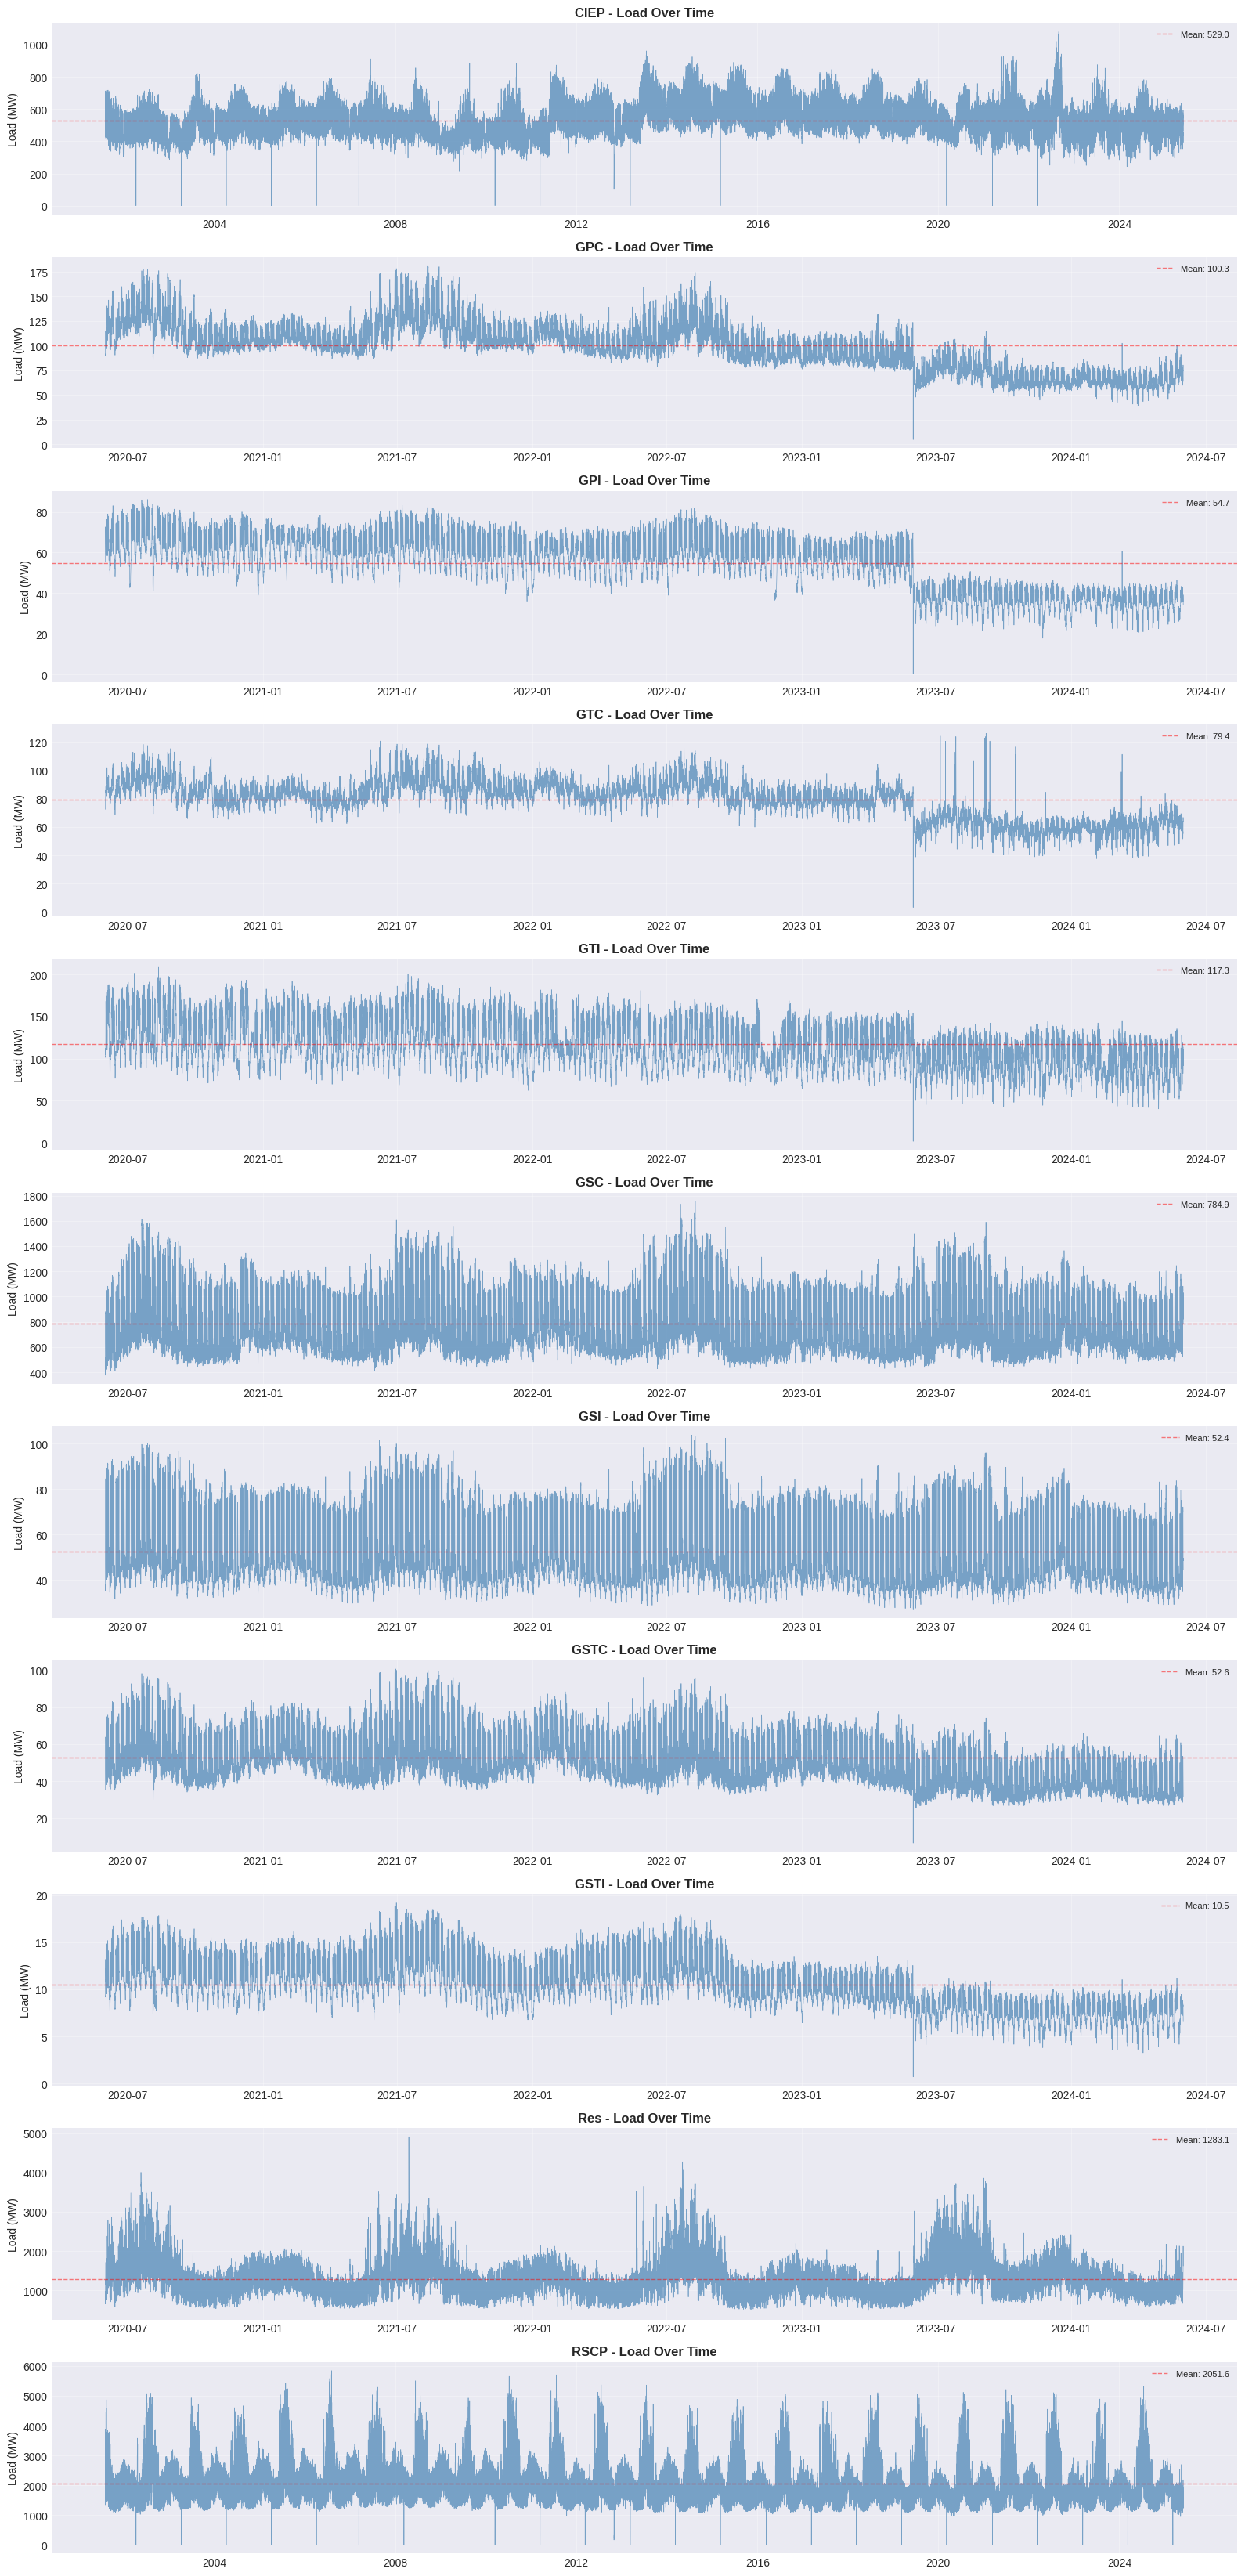

In [ ]:
# TIME SERIES

# Time Series Plot: all 11 customer classes plotted over time
#Useful to check is load is increasing or decreasing over the years
# Can use to check for patterns (can see seasonal peaks/dips)
# Can also use to check for anomalies (covid)
# Helps us understand if your data is stable, growing, or has major disruptions
# Different customer classes may show different patterns (ex., residential peaks in evening, industrial steady during workday)

print("GENERATING VISUALIZATIONS")


load_cols = list(load_data.keys())
n_classes = len(load_cols)
fig, axes = plt.subplots(n_classes, 1, figsize=(16, 3*n_classes))
if n_classes == 1:
    axes = [axes]

for idx, class_name in enumerate(load_cols):
    data = merged_df[['Date', class_name]].dropna()
    axes[idx].plot(data['Date'], data[class_name], linewidth=0.5, alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{class_name} - Load Over Time', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Load (MW)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

    # Add mean line
    mean_val = data[class_name].mean()
    axes[idx].axhline(mean_val, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'Mean: {mean_val:.1f}')
    axes[idx].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

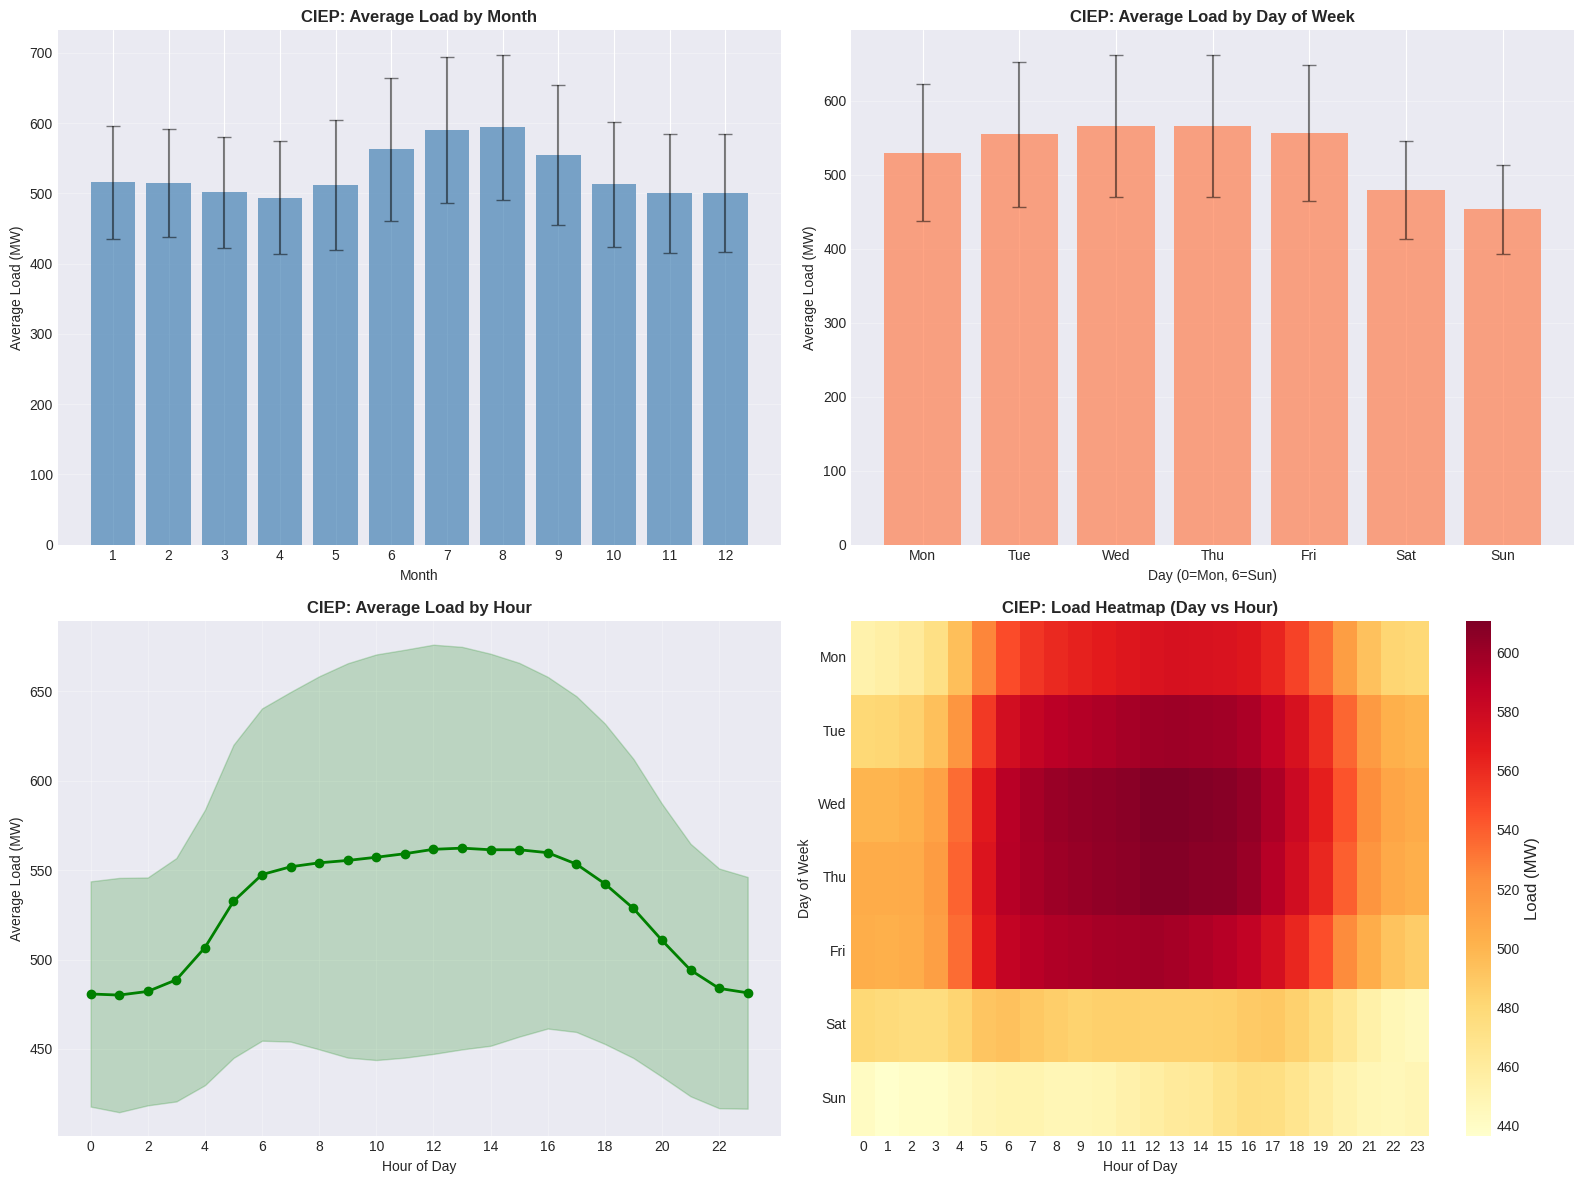

In [ ]:
# SEASONAL PATTERNS

# CIEP: Average load by month (top left)
# shows which months has highest/lowest load
# error bars for variation of each month

# CIEP: Average load by day of week (top right)
# shows which day has highest/lowest load
# error bars for variation

# CIEP: Average load by hour (bottom left)
# 24-hour load pattern to see when load peaks and dips in a day
# shaded area shows variability

# CIEP: Load Heatmap (day v hour)
# shows which day-hour combinations have highest load
# dark red = high load
# light yellow = low load

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 12  # Sets base font size (numeric)
mpl.rcParams['axes.titlesize'] = 'large'  # String: xx-small, x-small, small, medium, large, x-large, xx-large
mpl.rcParams['axes.labelsize'] = 'medium'
mpl.rcParams['xtick.labelsize'] = 'small'
mpl.rcParams['ytick.labelsize'] = 'small'

main_class = load_cols[0]
main_df = merged_df[[main_class, 'Month', 'DayOfWeek', 'Hour']].dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Monthly pattern
monthly = main_df.groupby('Month')[main_class].agg(['mean', 'std']).reset_index()
axes[0, 0].bar(monthly['Month'], monthly['mean'], color='steelblue', alpha=0.7)
axes[0, 0].errorbar(monthly['Month'], monthly['mean'], yerr=monthly['std'],
                    fmt='none', color='black', alpha=0.5, capsize=5)
axes[0, 0].set_title(f'{main_class}: Average Load by Month', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Month', fontsize=10)
axes[0, 0].set_ylabel('Average Load (MW)', fontsize=10)
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Day of week pattern
dow = main_df.groupby('DayOfWeek')[main_class].agg(['mean', 'std']).reset_index()
axes[0, 1].bar(dow['DayOfWeek'], dow['mean'], color='coral', alpha=0.7)
axes[0, 1].errorbar(dow['DayOfWeek'], dow['mean'], yerr=dow['std'],
                    fmt='none', color='black', alpha=0.5, capsize=5)
axes[0, 1].set_title(f'{main_class}: Average Load by Day of Week', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Day (0=Mon, 6=Sun)', fontsize=10)
axes[0, 1].set_ylabel('Average Load (MW)', fontsize=10)
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Hourly pattern
hourly = main_df.groupby('Hour')[main_class].agg(['mean', 'std']).reset_index()
axes[1, 0].plot(hourly['Hour'], hourly['mean'], color='green', marker='o', linewidth=2, markersize=6)
axes[1, 0].fill_between(hourly['Hour'],
                        hourly['mean'] - hourly['std'],
                        hourly['mean'] + hourly['std'],
                        alpha=0.2, color='green')
axes[1, 0].set_title(f'{main_class}: Average Load by Hour', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Hour of Day', fontsize=10)
axes[1, 0].set_ylabel('Average Load (MW)', fontsize=10)
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(True, alpha=0.3)

# Heatmap: Hour vs Day of Week
pivot_data = main_df.groupby(['DayOfWeek', 'Hour'])[main_class].mean().unstack()
sns.heatmap(pivot_data, ax=axes[1, 1], cmap='YlOrRd', cbar_kws={'label': 'Load (MW)'})
axes[1, 1].set_title(f'{main_class}: Load Heatmap (Day vs Hour)', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Hour of Day', fontsize=10)
axes[1, 1].set_ylabel('Day of Week', fontsize=10)
axes[1, 1].set_yticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# FIX: Round all dates to the nearest hour for proper alignment

print("FIXING DATE ALIGNMENT")

# Round weather dates to nearest hour
weather_df['Date'] = weather_df['Date'].dt.round('H')
print(f" Weather dates rounded to hour")
print(f"  New range: {weather_df['Date'].min()} to {weather_df['Date'].max()}")

# Rebuild merged dataframe with rounded dates
merged_df = weather_df.copy()

for class_name, df in load_data.items():
    # Round load dates too (just in case)
    df['Date'] = df['Date'].dt.round('H')
    merged_df = merged_df.merge(df, on='Date', how='outer')

# Re-add time features
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day
merged_df['DayOfWeek'] = merged_df['Date'].dt.dayofweek
merged_df['Hour'] = merged_df['Date'].dt.hour
merged_df['DayOfYear'] = merged_df['Date'].dt.dayofyear
merged_df['WeekOfYear'] = merged_df['Date'].dt.isocalendar().week
merged_df['Is_Weekend'] = merged_df['DayOfWeek'].isin([5, 6]).astype(int)

print(f" Merged dataset rebuilt: {merged_df.shape}")

# Check overlap now

print("CHECKING OVERLAP AFTER FIX")

for class_name in load_cols[:3]:
    subset = merged_df[['Temperature', class_name]].dropna()
    print(f"Temperature + {class_name}: {len(subset):,} rows")
    if len(subset) > 0:
        print(f"  Date range: {subset.index.min()} to {subset.index.max()}")

# Save fixed merged data
merged_df.to_csv('merged_load_weather_data.csv', index=False)

FIXING DATE ALIGNMENT
 Weather dates rounded to hour
  New range: 2019-01-01 01:00:00 to 2025-01-01 00:00:00
 Merged dataset rebuilt: (208920, 29)
CHECKING OVERLAP AFTER FIX
Temperature + CIEP: 52,400 rows
  Date range: 152690 to 205297
Temperature + GPC: 34,918 rows
  Date range: 165096 to 200159
Temperature + GPI: 34,918 rows
  Date range: 165096 to 200159


✓ Saved: 03_correlation_heatmap.png


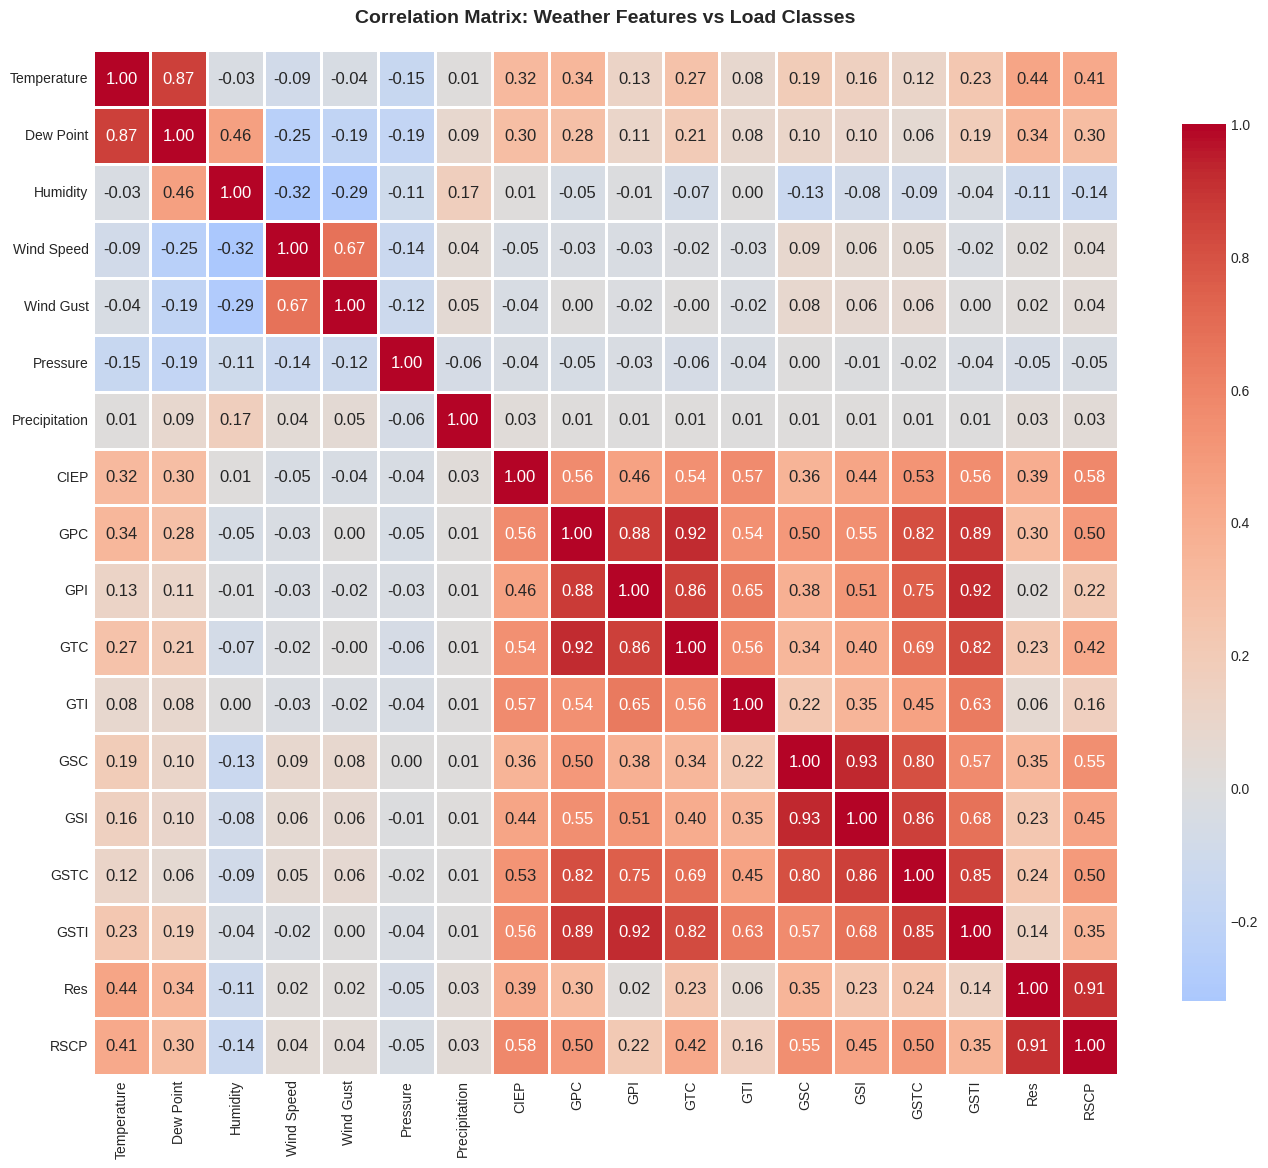


 TOP WEATHER CORRELATIONS WITH LOAD:

CIEP:
Temperature      0.323078
Dew Point        0.296089
Precipitation    0.029286
Humidity         0.011000
Wind Gust       -0.037113
Pressure        -0.042527
Wind Speed      -0.045231

GPC:
Temperature      0.337260
Dew Point        0.281683
Precipitation    0.013776
Wind Gust        0.000010
Wind Speed      -0.032341
Humidity        -0.048023
Pressure        -0.051304

GPI:
Temperature      0.126768
Dew Point        0.111885
Precipitation    0.005503
Humidity        -0.013284
Wind Gust       -0.016293
Wind Speed      -0.033235
Pressure        -0.033707


In [ ]:
# CORRELATION ANALYSIS

# Shows how strongly each weather variable relates to each load class
# +1.00 (dark red) = perfect positive correlation (when X goes up, Y goes up)
# 0.0 (white) = no correlation
# -1.0 (dark blue) = perfect negative correlation (when X goes up, Y goes down)

# this tells us which weather feature are most important for predicting load
# strong correlations are useful predictors

corr_cols = numeric_cols + load_cols
corr_data = merged_df[corr_cols].dropna()

if len(corr_data) > 0:
    plt.figure(figsize=(14, 12))
    correlation_matrix = corr_data.corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix: Weather Features vs Load Classes',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('03_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 03_correlation_heatmap.png")
    plt.show()

    # Print top correlations
    print("\n TOP WEATHER CORRELATIONS WITH LOAD:")
    for load_class in load_cols[:3]:
        if load_class in correlation_matrix.columns:
            print(f"\n{load_class}:")
            correlations = correlation_matrix[load_class][numeric_cols].sort_values(ascending=False)
            print(correlations.to_string())

Saved: temp_vs_load_rscp_ciep.png


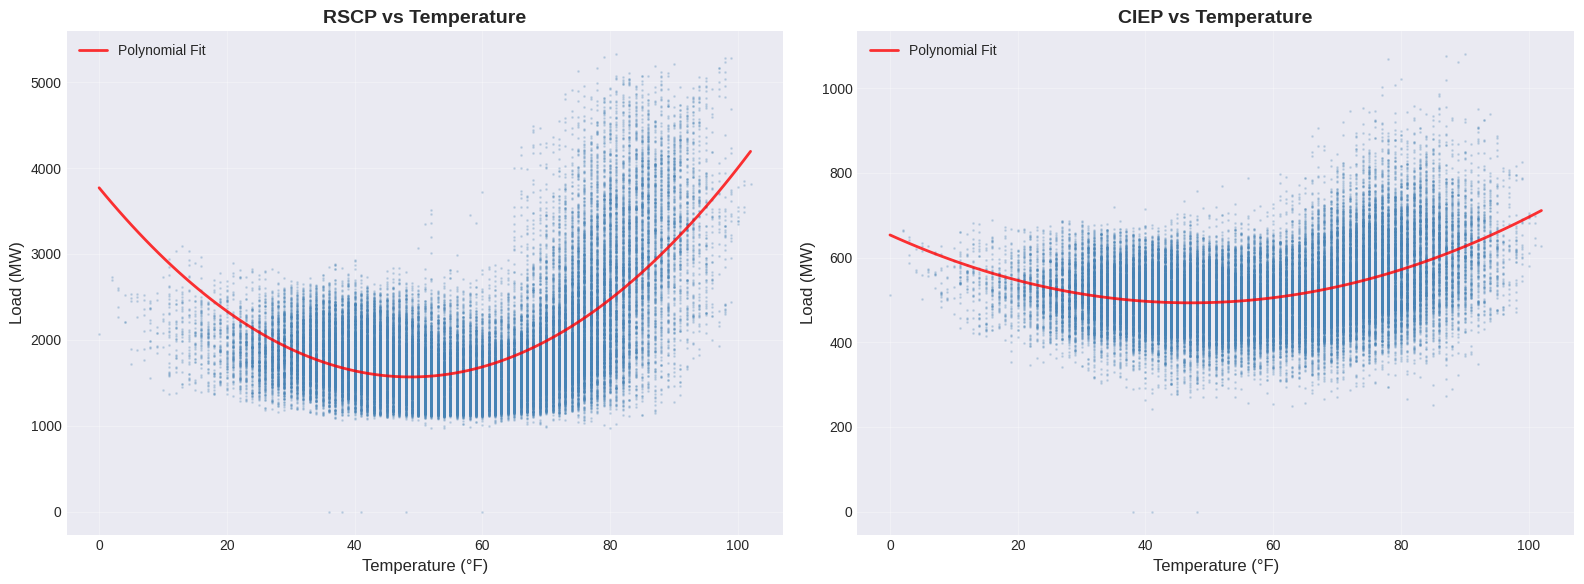

In [ ]:
# TEMPERATURE vs LOAD - ONLY RSCP AND CIEP

if 'Temperature' in merged_df.columns:
    # Only plot RSCP and CIEP
    classes_to_plot = ['RSCP', 'CIEP']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for idx, class_name in enumerate(classes_to_plot):
        if class_name in merged_df.columns:
            plot_data = merged_df[['Temperature', class_name]].dropna()

            if len(plot_data) > 0:
                # Scatter plot
                axes[idx].scatter(plot_data['Temperature'], plot_data[class_name],
                                alpha=0.2, s=1, c='steelblue')

                # Add trend line
                if len(plot_data) > 100:
                    z = np.polyfit(plot_data['Temperature'], plot_data[class_name], 2)
                    p = np.poly1d(z)
                    temp_range = np.linspace(plot_data['Temperature'].min(),
                                            plot_data['Temperature'].max(), 100)
                    axes[idx].plot(temp_range, p(temp_range), "r-", linewidth=2, alpha=0.8,
                                  label='Polynomial Fit')

                axes[idx].set_title(f'{class_name} vs Temperature', fontweight='bold', fontsize=14)
                axes[idx].set_xlabel('Temperature (°F)', fontsize=12)
                axes[idx].set_ylabel('Load (MW)', fontsize=12)
                axes[idx].grid(True, alpha=0.3)
                axes[idx].legend(fontsize=10)
        else:
            axes[idx].text(0.5, 0.5, f'{class_name} not found',
                          ha='center', va='center', fontsize=12)
            axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('temp_vs_load_rscp_ciep.png', dpi=300, bbox_inches='tight')
    print("Saved: temp_vs_load_rscp_ciep.png")
    plt.show()

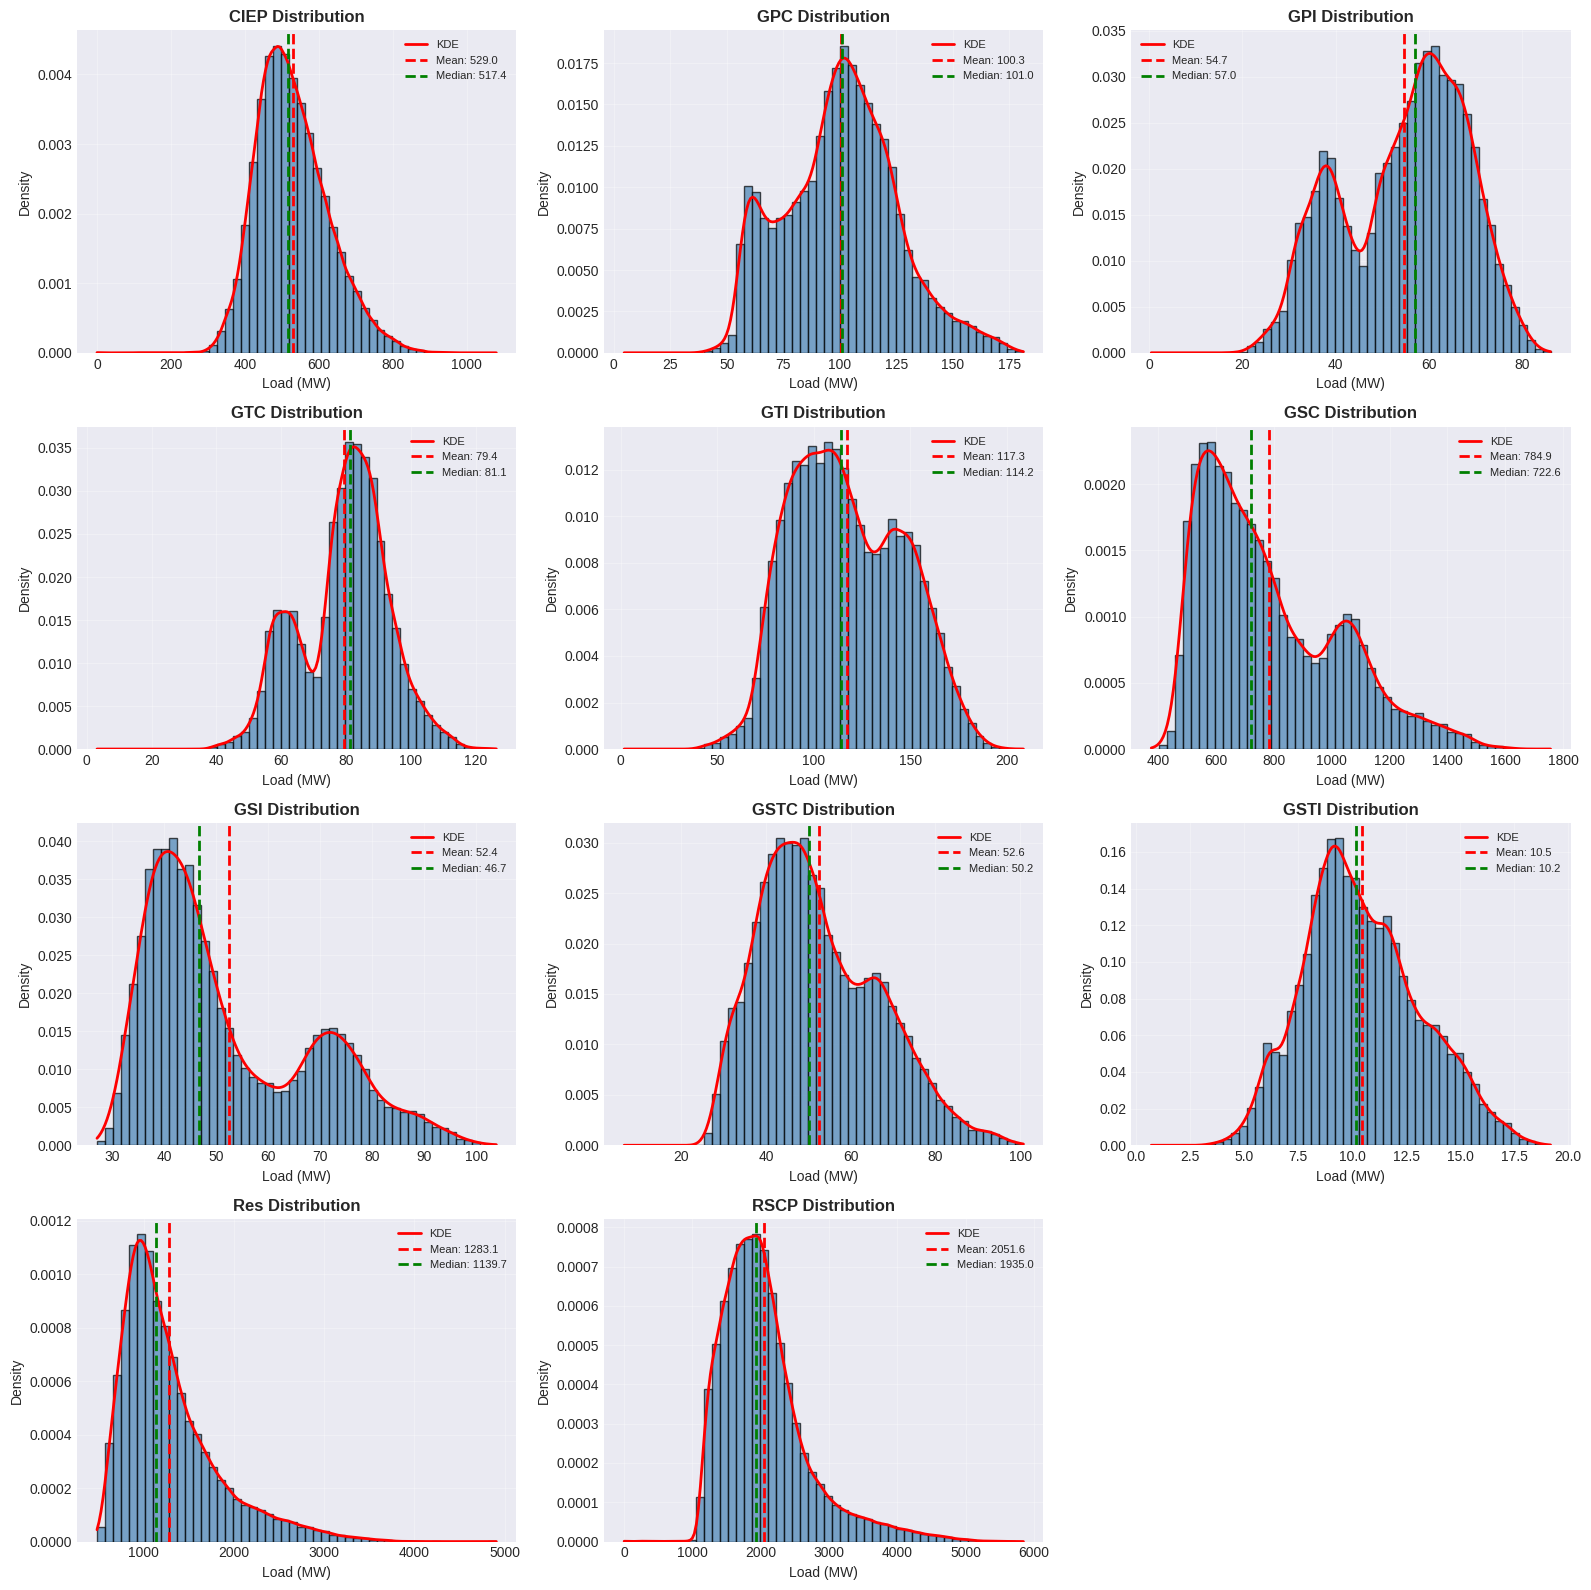

In [ ]:
# LOAD DISTRIBUTIONS

# shows us how often different load values occur (histogram and density curve)
# red line = mean
# green line = median
# red curve = smooth estimate of distribution

n_cols = 3
n_rows = (len(load_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten() if len(load_cols) > 1 else [axes]

for idx, class_name in enumerate(load_cols):
    data = merged_df[class_name].dropna()

    if len(data) > 0:
        # Histogram
        axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue', density=True)

        # Add KDE
        if len(data) > 100:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(data)
            x_range = np.linspace(data.min(), data.max(), 200)
            axes[idx].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

        # Statistics
        mean_val = data.mean()
        median_val = data.median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                         label=f'Mean: {mean_val:.1f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2,
                         label=f'Median: {median_val:.1f}')

        axes[idx].set_title(f'{class_name} Distribution', fontweight='bold')
        axes[idx].set_xlabel('Load (MW)')
        axes[idx].set_ylabel('Density')
        axes[idx].legend(fontsize=8)
        axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(load_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# OUTLIER DETECTION


print("\n" + "="*80)
print("OUTLIER DETECTION (Z-Score > 3)")
print("="*80)

outlier_summary = []
for class_name in load_cols:
    data = merged_df[class_name].dropna()
    if len(data) > 0:
        z_scores = np.abs(stats.zscore(data))
        outliers = np.sum(z_scores > 3)
        pct = (outliers / len(data)) * 100
        outlier_summary.append({
            'Class': class_name,
            'Outliers': outliers,
            'Percentage': pct,
            'Total Records': len(data)
        })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))


OUTLIER DETECTION (Z-Score > 3)
Class  Outliers  Percentage  Total Records
 CIEP      1101    0.526996         208920
  GPC        35    0.099817          35064
  GPI         1    0.002852          35064
  GTC        21    0.059890          35064
  GTI         2    0.005704          35064
  GSC       104    0.296601          35064
  GSI        14    0.039927          35064
 GSTC        89    0.253822          35064
 GSTI        14    0.039927          35064
  Res       598    1.705453          35064
 RSCP      4070    1.948114         208920


YEARLY LOAD TRENDS
        CIEP     GPC    GPI    GTC     GTI     GSC    GSI   GSTC   GSTI  \
Year                                                                      
2001  489.60     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2002  479.85     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2003  481.55     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2004  510.95     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2005  519.78     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2006  530.23     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2007  522.51     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2008  498.29     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2009  439.82     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2010  466.61     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2011  517.79     NaN    NaN    NaN     NaN     NaN    NaN    NaN    NaN   
2012  

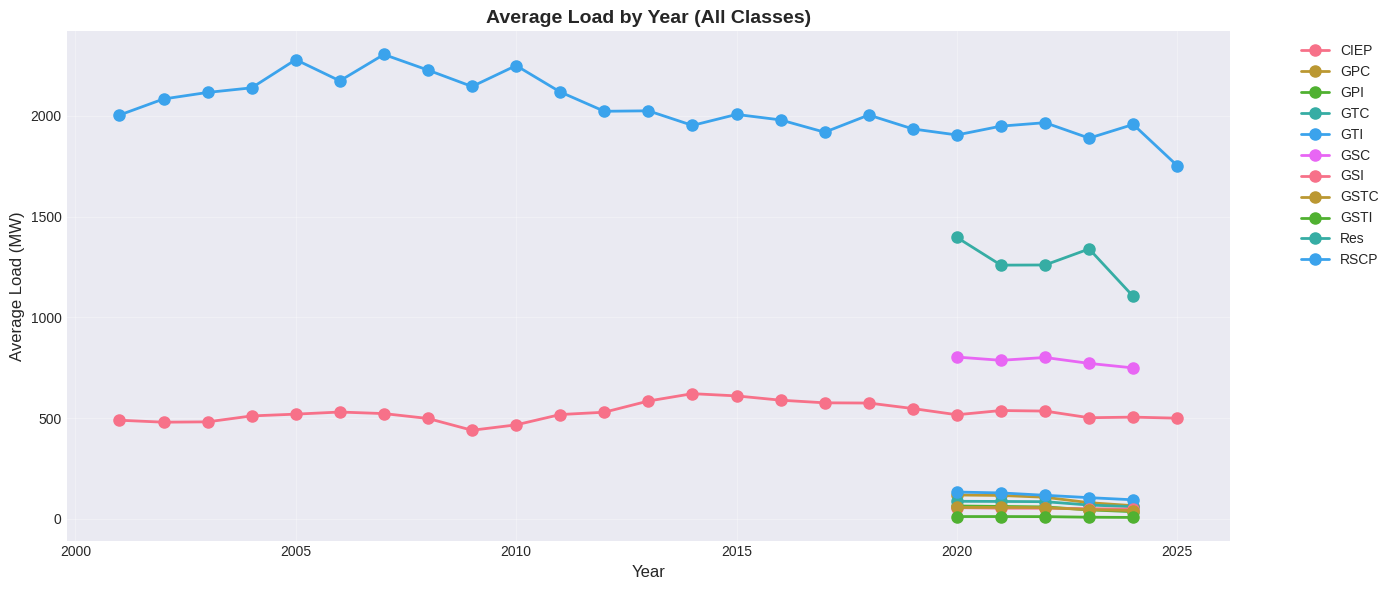

In [ ]:
# YEARLY TRENDS

# shows us the average load for each customer class over the years
# we can see long-term trends that affect the forecast

print("YEARLY LOAD TRENDS")
print("="*80)

yearly_data = merged_df.groupby('Year')[load_cols].mean()
print(yearly_data.round(2))

fig, ax = plt.subplots(figsize=(14, 6))
for class_name in load_cols:
    if class_name in yearly_data.columns:
        ax.plot(yearly_data.index, yearly_data[class_name],
                marker='o', linewidth=2, label=class_name, markersize=8)

ax.set_title('Average Load by Year (All Classes)', fontweight='bold', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Baseline Model

A simple baseline pipeline with:
- Feature engineering: hour-of-day, day-of-week, holidays, lag features
- Baselines: Linear Regression (with lag/time features) and ARIMA
- Evaluation: MAE, RMSE, MAPE
- Instructions to adapt to your JCPL dataset

In [ ]:
!pip install pandas numpy scikit-learn statsmodels holidays matplotlib seaborn --quiet

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [ ]:
import zipfile
import os
import pandas as pd

# --- Step 1: Upload and unzip ---
from google.colab import files
uploaded = files.upload()   # Upload 2025-Data.zip

zip_path = "2025-Data.zip"
extract_path = "/content/2025-Data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped to:", extract_path)

Saving 2025-Data.zip to 2025-Data (4).zip
Unzipped to: /content/2025-Data


In [ ]:
# BASE_PATH = r'/content/2025-Data/Data/cleaned rate class data'
BASE_PATH = os.path.join('/content/2025-Data/2025-Data/Data',
                         'cleaned rate class data')

# Load all Excel files
files = [f for f in os.listdir(BASE_PATH) if f.endswith(".xlsx")]
print("Found files:", files)

data_dict = {}
for f in files:
    df = pd.read_excel(os.path.join(BASE_PATH, f))
    df.columns = ["timestamp", "load"]  # ensure consistent names
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    data_dict[f.replace("_cleaned.xlsx", "")] = df

print("Loaded datasets:", list(data_dict.keys()))

FileNotFoundError: [Errno 2] No such file or directory: '/content/2025-Data/2025-Data/Data/cleaned rate class data'

Rate classes:   0%|          | 0/11 [00:00<?, ?series/s]


🔹 Processing rate class: GPC
  Linear Regression: {'MAE': 1.5968993755137986, 'RMSE': 2.0586073876384248, 'MAPE%': 2.2766891139703245}
  ARIMA: {'MAE': 10.037041449914408, 'RMSE': 12.247692705191856, 'MAPE%': 13.426670534415777}


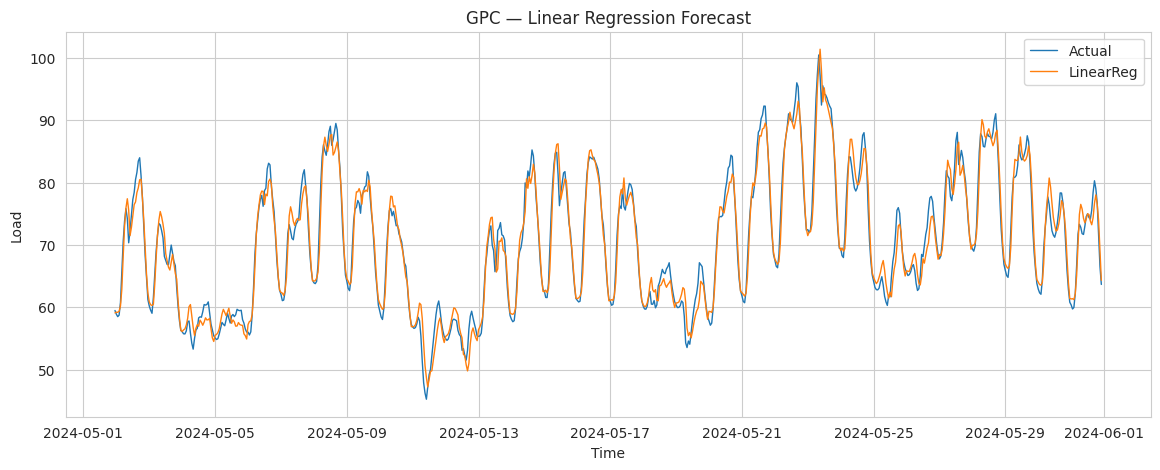

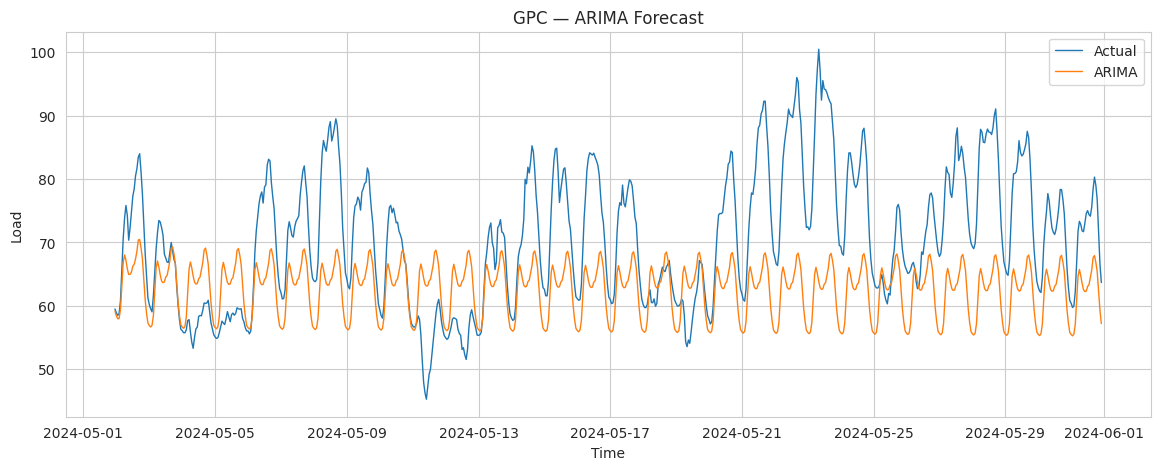

Rate classes:   9%|▉         | 1/11 [10:26<1:44:29, 626.99s/series]


🔹 Processing rate class: GTI
  Linear Regression: {'MAE': 6.014029858889809, 'RMSE': 8.137230832218929, 'MAPE%': 6.467320827399916}


In [ ]:
#Session crashed after using all available RAM. Baseline modeling per rate class (robust & fault-tolerant)

from tqdm import tqdm
import traceback
import pandas as pd
import os

results_summary = {}
problem_logs = []

MIN_TRAIN_HOURS = 24 * 7    # require at least 1 week of training after feature drop
TEST_HOURS = 24 * 30        # last 30 days as test

for name, df in tqdm(data_dict.items(), desc="Rate classes", unit="series"):
    try:
        print(f"\n🔹 Processing rate class: {name}")
        feat = make_features(df)

        if len(feat) < (MIN_TRAIN_HOURS + TEST_HOURS + 1):
            msg = f"Skipping {name}: not enough data after feature creation (rows={len(feat)})"
            print(msg)
            problem_logs.append({"rate_class": name, "error": msg})
            continue

        # Train-test split
        train_df = feat[:-TEST_HOURS].copy()
        test_df  = feat[-TEST_HOURS:].copy()

        X_cols = [c for c in feat.columns if c not in ["timestamp", "load"]]
        X_train, X_test = train_df[X_cols], test_df[X_cols]
        y_train, y_test = train_df["load"], test_df["load"]

        # ---------- Linear Regression ----------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        lr = LinearRegression()
        lr.fit(X_train_scaled, y_train)
        pred_lr = lr.predict(X_test_scaled)
        metrics_lr = evaluate(y_test.values, pred_lr)
        print("  Linear Regression:", metrics_lr)

        # ---------- ARIMA (SARIMAX) ----------
        # If SARIMAX fails we will catch the exception and log it.
        train_series = train_df.set_index("timestamp")["load"]
        test_series = test_df.set_index("timestamp")["load"]
        metrics_arima = None
        pred_arima = None

        try:
            model = sm.tsa.statespace.SARIMAX(train_series,
                                              order=(2,1,2),
                                              seasonal_order=(1,1,1,24),
                                              enforce_stationarity=False,
                                              enforce_invertibility=False)
            arima_fit = model.fit(disp=False)
            pred_arima = arima_fit.forecast(steps=len(test_series))
            # ensure numpy array
            pred_arima_vals = np.asarray(pred_arima).astype(float)
            metrics_arima = evaluate(test_series.values, pred_arima_vals)
            print("  ARIMA:", metrics_arima)
        except Exception as e_ar:
            tb = traceback.format_exc()
            msg = f"ARIMA fit failed for {name}: {repr(e_ar)}"
            print("  " + msg)
            problem_logs.append({"rate_class": name, "error": msg, "traceback": tb})

        # ---------- Store results ----------
        results_summary[name] = {
            "Linear Regression": metrics_lr,
            "ARIMA": metrics_arima
        }

        # ---------- Plot (optional) ----------
        try:
            plot_forecast(test_df, y_test.values, pred_lr, "LinearReg", f"{name} — Linear Regression Forecast")
            if pred_arima is not None:
                plot_forecast(test_df, test_series.values, pred_arima.values if hasattr(pred_arima, "values") else pred_arima, "ARIMA", f"{name} — ARIMA Forecast")
        except Exception as e_plot:
            print(f"  Warning: plotting failed for {name}: {e_plot}")

    except Exception as e:
        tb = traceback.format_exc()
        print(f"ERROR processing {name}: {e}\n{tb}")
        problem_logs.append({"rate_class": name, "error": str(e), "traceback": tb})
        continue

# Save results summary to CSV
out_rows = []
for rate, models in results_summary.items():
    for model_name, metrics in models.items():
        if metrics is None:
            out_rows.append({"rate_class": rate, "model": model_name, "MAE": None, "RMSE": None, "MAPE%": None})
        else:
            out_rows.append({"rate_class": rate, "model": model_name,
                             "MAE": metrics["MAE"], "RMSE": metrics["RMSE"], "MAPE%": metrics["MAPE%"]})
results_df = pd.DataFrame(out_rows)
results_df.to_csv(os.path.join(BASE_PATH, "Baseline_Results.csv"), index=False)
print("\nSaved Baseline_Results.csv to:", os.path.join(BASE_PATH, "Baseline_Results.csv"))

# Save problem logs
if problem_logs:
    pd.DataFrame(problem_logs).to_csv(os.path.join(BASE_PATH, "Baseline_Problems.csv"), index=False)
    print("Saved Baseline_Problems.csv with", len(problem_logs), "entries.")


In [ ]:
results_df = pd.DataFrame({
    (rate, model): metrics
    for rate, models in results_summary.items()
    for model, metrics in models.items()
}).T

display(results_df.round(3))

hey all :)   - DW

how to pickle models so you do not have to rerun each time you want add more data for predicting (aka expand the forecast time window), or chagne metrics

https://www.datacamp.com/tutorial/pickle-python-tutorial

https://stackoverflow.com/questions/48295661/how-to-pickle-keras-model


https://stackoverflow.com/questions/71492778/how-to-save-tensorflow-model-to-pickle-file


https://stackoverflow.com/questions/56107259/how-to-save-a-trained-model-by-scikit-learn


### By time

In [ ]:
import os
import gc
import pickle
import traceback
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
import matplotlib.pyplot as plt
import holidays
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Evaluation
def evaluate(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE%": mape}

def plot_forecast(df, y_true, y_pred, model_name, title, max_points=720):
    plt.figure(figsize=(14,5))
    df_plot = df.iloc[-max_points:]
    plt.plot(df_plot["timestamp"], y_true[-max_points:], label="Actual", linewidth=1)
    plt.plot(df_plot["timestamp"], y_pred[-max_points:], label=model_name, linewidth=1)
    plt.legend()
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Load")
    plt.show()

In [ ]:
#Baseline Training
BASE_PATH = "/content/2025-Data/2025-Data/Data/cleaned rate class data"
files = [f for f in os.listdir(BASE_PATH) if f.endswith(".xlsx")]

data_dict = {}
for f in files:
    df = pd.read_excel(os.path.join(BASE_PATH, f))
    df.columns = ["timestamp", "load"]
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    data_dict[f.replace("_cleaned.xlsx", "")] = df

results_summary = []
problem_logs = []
save_dir = os.path.join(BASE_PATH, "saved_models")
os.makedirs(save_dir, exist_ok=True)

FileNotFoundError: [Errno 2] No such file or directory: '/content/2025-Data/2025-Data/Data/cleaned rate class data'

In [ ]:
for name, df in tqdm(data_dict.items(), desc="Rate classes", unit="series"):
    try:
        print(f"\n🔹 Processing rate class: {name}")
        feat = make_features(df)

        # STRICT train/test by calendar year
        train_df = feat[(feat["year"] >= 2022) & (feat["year"] <= 2023)].copy()
        test_df = feat[feat["year"] >= 2024].copy()

        if len(train_df) < 24 * 30 or len(test_df) < 24 * 7:
            msg = f"Skipping {name}: insufficient data in 2022–2024 window."
            print(msg)
            problem_logs.append({"rate_class": name, "error": msg})
            continue

        # Prepare features (no timestamp or leakage columns)
        X_cols = [c for c in feat.columns if c not in ["timestamp", "load", "year"]]
        X_train, y_train = train_df[X_cols], train_df["load"]
        X_test, y_test = test_df[X_cols], test_df["load"]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # --- Linear Regression ---
        lr = LinearRegression()
        lr.fit(X_train_scaled, y_train)
        y_pred_lr = lr.predict(X_test_scaled)
        metrics_lr = evaluate(y_test, y_pred_lr)
        print("  Linear Regression:", metrics_lr)

        with open(os.path.join(save_dir, f"{name}_LR.pkl"), "wb") as f:
            pickle.dump({"model": lr, "scaler": scaler}, f)

        # --- ARIMA ---
        train_series = train_df.set_index("timestamp")["load"]
        test_series = test_df.set_index("timestamp")["load"]
        metrics_arima, y_pred_arima = None, None

        try:
            model = sm.tsa.statespace.SARIMAX(
                train_series,
                order=(2,1,2),
                seasonal_order=(1,1,1,24),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            arima_fit = model.fit(disp=False)
            y_pred_arima = arima_fit.forecast(steps=len(test_series))
            metrics_arima = evaluate(test_series.values, y_pred_arima)
            print("  ARIMA:", metrics_arima)

            with open(os.path.join(save_dir, f"{name}_ARIMA.pkl"), "wb") as f:
                pickle.dump(arima_fit, f)

        except Exception as e_ar:
            tb = traceback.format_exc()
            msg = f"ARIMA failed for {name}: {e_ar}"
            print("  " + msg)
            problem_logs.append({"rate_class": name, "error": msg, "traceback": tb})

        # --- Store results ---
        results_summary.append({
            "rate_class": name,
            "model": "Linear Regression",
            **metrics_lr
        })
        if metrics_arima is not None:
            results_summary.append({
                "rate_class": name,
                "model": "ARIMA",
                **metrics_arima
            })

        plot_forecast(test_df, y_test, y_pred_lr, "Linear Regression", f"{name} (2024 Forecast)")
        if y_pred_arima is not None:
            plot_forecast(test_df, test_series.values, y_pred_arima, "ARIMA", f"{name} (2024 Forecast)")

    except Exception as e:
        tb = traceback.format_exc()
        print(f"Error in {name}: {e}")
        problem_logs.append({"rate_class": name, "error": str(e), "traceback": tb})
    finally:
        gc.collect()

Rate classes:   0%|          | 0/11 [00:00<?, ?series/s]


🔹 Processing rate class: GSC
  Linear Regression: {'MAE': 28.8074127442815, 'RMSE': np.float64(36.6617114641437), 'MAPE%': np.float64(3.9996890758433863)}
  ARIMA: {'MAE': 553.9940019899548, 'RMSE': np.float64(622.8852610585575), 'MAPE%': np.float64(81.38853255106251)}


In [ ]:
results_df = pd.DataFrame(results_summary)
results_df.to_csv(os.path.join(BASE_PATH, "Baseline_Results.csv"), index=False)
print("\nSaved Baseline_Results.csv")

if problem_logs:
    pd.DataFrame(problem_logs).to_csv(os.path.join(BASE_PATH, "Baseline_Problems.csv"), index=False)
    print(f"Logged {len(problem_logs)} problems.")

## LSTM


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
from google.colab import files
import zipfile
import os
from pathlib import Path
import pandas as pd
import shutil

# --- Step 1: Upload all your files ---
# Upload your 2025-Data.zip AND all cleaned files in one go
uploaded = files.upload()

# --- Step 2: Unzip the main zip file ---
zip_path = "2025-Data.zip"
extract_path = Path("/content/2025-Data")

if Path(zip_path).exists():
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Unzipped main folder to:", extract_path)
else:
    print("⚠️ 2025-Data.zip not found — skipping unzip step")

# --- Step 3: Create the 'cleaned rate class data' folder ---
cleaned_folder = extract_path / "Data" / "cleaned rate class data"
cleaned_folder.mkdir(parents=True, exist_ok=True)
print(f"📁 Created/verified folder: {cleaned_folder}")

# --- Step 4: Move all uploaded *_cleaned.csv or *_cleaned.xlsx files into that folder ---
for filename in uploaded.keys():
    if ("cleaned" in filename.lower()) and (filename.endswith((".csv", ".xlsx"))):
        src = Path("/content") / filename
        dest = cleaned_folder / filename
        shutil.move(str(src), str(dest))
        print(f"Moved: {filename} → {dest}")

# --- ✅ Step 5: Load all cleaned files (only keep first 2 columns) ---
data_dict = {}

for f in cleaned_folder.iterdir():
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f)
    elif f.suffix.lower() == ".xlsx":
        df = pd.read_excel(f)
    else:
        continue

    print(f"🔹 Loading {f.name} → original columns: {list(df.columns)}")

    # ✅ Keep only the first two columns
    df = df.iloc[:, :2]
    df.columns = ["timestamp", "load"]

    # Clean timestamp column
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    df["year"] = df["timestamp"].dt.year

    # Save in dictionary
    key = f.stem.replace("_cleaned", "")
    data_dict[key] = df
    print(f"✅ Loaded: {key} ({len(df)} rows, columns={df.columns.tolist()})")

print(f"\n✅ Finished loading {len(data_dict)} cleaned datasets.")
print("All organized under:", cleaned_folder)





Saving 2025-Data.zip to 2025-Data.zip
Saving CIEP_cleaned.csv to CIEP_cleaned.csv
Saving GPC_cleaned.csv to GPC_cleaned.csv
Saving GPI_cleaned.csv to GPI_cleaned.csv
Saving GSC_cleaned.csv to GSC_cleaned.csv
Saving GTI_cleaned.csv to GTI_cleaned.csv
Saving GTC_cleaned.csv to GTC_cleaned.csv
Saving GSTI_cleaned.csv to GSTI_cleaned.csv
Saving GSTC_cleaned.csv to GSTC_cleaned.csv
Saving GSI_cleaned.csv to GSI_cleaned.csv
Saving Res_cleaned.csv to Res_cleaned.csv
Saving RSCP_cleaned.csv to RSCP_cleaned.csv
✅ Unzipped main folder to: /content/2025-Data
📁 Created/verified folder: /content/2025-Data/Data/cleaned rate class data
Moved: CIEP_cleaned.csv → /content/2025-Data/Data/cleaned rate class data/CIEP_cleaned.csv
Moved: GPC_cleaned.csv → /content/2025-Data/Data/cleaned rate class data/GPC_cleaned.csv
Moved: GPI_cleaned.csv → /content/2025-Data/Data/cleaned rate class data/GPI_cleaned.csv
Moved: GSC_cleaned.csv → /content/2025-Data/Data/cleaned rate class data/GSC_cleaned.csv
Moved: GTI_cl

In [ ]:
!pip install pandas numpy scikit-learn statsmodels holidays matplotlib seaborn --quiet
import numpy as np
import pandas as pd
import holidays

In [ ]:
# Cell 4 — Basic resampling & feature creation

us_holidays = holidays.UnitedStates()

def make_features(df):
    """Feature engineering: time-based + lag + rolling + holiday features"""
    df = df.copy()
    df = df.set_index("timestamp")
    # Ensure hourly frequency
    df = df.resample("H").mean().interpolate().fillna(method="bfill")
    df = df.reset_index()

    df["hour"] = df["timestamp"].dt.hour
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["is_holiday"] = df["timestamp"].dt.date.apply(lambda d: 1 if d in us_holidays else 0)

    # Cyclic encodings
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    # Lags & rolling stats
    for lag in [1, 24, 168]:
        df[f"lag_{lag}"] = df["load"].shift(lag)
    df["rolling_24_mean"] = df["load"].shift(1).rolling(24).mean()
    df["rolling_24_std"] = df["load"].shift(1).rolling(24).std()
    df = df.dropna().reset_index(drop=True)
    return df

In [ ]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

problem_logs = []

for name, df in tqdm(data_dict.items(), desc="Rate classes", unit="series"):
    try:
        print(f"\n🔹 Processing rate class: {name}")
        feat = make_features(df)

        # STRICT train/test by calendar year
        train_df = feat[(feat["year"] >= 2022) & (feat["year"] <= 2023)].copy()
        test_df = feat[feat["year"] >= 2024].copy()

        if len(train_df) < 24 * 30 or len(test_df) < 24 * 7:
            msg = f"Skipping {name}: insufficient data in 2022–2024 window."
            print(msg)
            problem_logs.append({"rate_class": name, "error": msg})
            continue

        # Prepare features (no timestamp or leakage columns)
        X_cols = [c for c in feat.columns if c not in ["timestamp", "load", "year"]]
        X_train, y_train = train_df[X_cols], train_df["load"]
        X_test, y_test = test_df[X_cols], test_df["load"]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        print(f"✅ Finished scaling for {name}")

    except Exception as e:
        msg = f"❌ Error processing {name}: {e}"
        print(msg)
        problem_logs.append({"rate_class": name, "error": str(e)})


Rate classes:   0%|          | 0/11 [00:00<?, ?series/s]/tmp/ipython-input-3634912659.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
/tmp/ipython-input-3634912659.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
Rate classes:   9%|▉         | 1/11 [00:00<00:02,  4.87series/s]


🔹 Processing rate class: GSTI
✅ Finished scaling for GSTI

🔹 Processing rate class: Res


/tmp/ipython-input-3634912659.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
/tmp/ipython-input-3634912659.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
Rate classes:  18%|█▊        | 2/11 [00:00<00:01,  5.78series/s]/tmp/ipython-input-3634912659.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
/tmp/ipython-input-3634912659.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")


✅ Finished scaling for Res

🔹 Processing rate class: CIEP


Rate classes:  27%|██▋       | 3/11 [00:01<00:06,  1.20series/s]

...

✅ Finished scaling for GPI

🔹 Processing rate class: GSC


/tmp/ipython-input-3634912659.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
/tmp/ipython-input-3634912659.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
Rate classes:  91%|█████████ | 10/11 [00:06<00:00,  1.67series/s]

✅ Finished scaling for GSC

🔹 Processing rate class: GSI


/tmp/ipython-input-3634912659.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
/tmp/ipython-input-3634912659.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.resample("H").mean().interpolate().fillna(method="bfill")
Rate classes: 100%|██████████| 11/11 [00:06<00:00,  1.67series/s]

✅ Finished scaling for GSI


In [ ]:
# need to get the input into sequences for the LSTM to take in as input



def create_sequences(X, y, lookback=24):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

lookback = 24
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, lookback)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, lookback)


In [ ]:
# build model


model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(lookback, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# train model

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - loss: 2116.9717 - val_loss: 812.2322
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 899.3476 - val_loss: 335.5537
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 453.7321 - val_loss: 194.4183
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 312.3648 - val_loss: 177.8440
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 279.5010 - val_loss: 184.3002
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 281.9083 - val_loss: 187.1148
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 273.4946 - val_loss: 186.9036
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 198.0978 - val_loss: 25.0458
Epoch 9/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 82.5603 - val_loss: 7.9330
Epoch 10/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 48.9609 - val_loss: 7.0166
Epoch 11/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - loss: 38.1094 - val_loss: 7.

In [ ]:
# make predictions
y_pred = model.predict(X_test_seq)

114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Metrics
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
mae = mean_absolute_error(y_test_seq, y_pred)
mape = np.mean(np.abs((y_test_seq - y_pred) / y_test_seq)) * 100
r2 = r2_score(y_test_seq, y_pred)

print(f"Model Evaluation Metrics:")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.3f}")



Model Evaluation Metrics:
RMSE: 1.760
MAE: 1.276
MAPE: 30.40%
R²: 0.983


In [ ]:
# --- Optional: Plot predictions vs. actuals ---
plt.figure(figsize=(10, 5))
plt.plot(y_true[:500], label="Actual", linewidth=2)
plt.plot(y_pred[:500], label="Predicted", linewidth=2)
plt.title("🔮 LSTM Forecast vs Actual Load (first 500 samples)")
plt.xlabel("Time Steps")
plt.ylabel("Load")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'y_true' is not defined

<Figure size 1000x500 with 0 Axes>

## k Fold on LSTM

In [ ]:
!pip install -q tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
import os
warnings.filterwarnings('ignore')

print("="*80)
print("LSTM K-FOLD CROSS-VALIDATION FOR LOAD FORECASTING")
print("="*80)
print(f"TensorFlow version: {tf.__version__}")

LSTM K-FOLD CROSS-VALIDATION FOR LOAD FORECASTING
TensorFlow version: 2.19.0


In [ ]:
# ============================================
# METRIC FUNCTIONS (MATCHING THE PATTERN)
# ============================================

def smape(true, pred):
    """Symmetric Mean Absolute Percentage Error"""
    denom = (np.abs(true) + np.abs(pred)) / 2.0
    denom = np.where(denom == 0, 1e-6, denom)
    return np.mean(np.abs(true - pred) / denom) * 100.0

def compute_metrics(true, pred):
    """Compute all evaluation metrics"""
    mae = mean_absolute_error(true, pred)
    rmse = float(np.sqrt(((true - pred) ** 2).mean()))
    mape = float(np.mean(np.abs((true - pred) / np.maximum(np.abs(true), 1e-6))) * 100.0)
    smp = float(smape(true, pred))
    r2 = r2_score(true, pred)

    return {
        "MAE": float(mae),
        "RMSE": rmse,
        "MAPE%": mape,
        "SMAPE%": smp,
        "R²": float(r2)
    }

In [ ]:
# ============================================
# DATA PREPARATION
# ============================================
print("\n📊 Loading merged data...")

# Load the merged dataset from EDA
merged_df = pd.read_csv('merged_load_weather_data.csv', parse_dates=['Date'])
print(f"✓ Loaded: {merged_df.shape}")
print(f"Date range: {merged_df['Date'].min()} to {merged_df['Date'].max()}")


📊 Loading merged data...
✓ Loaded: (261528, 29)
Date range: 2001-07-31 23:00:00 to 2025-05-31 22:00:00


In [ ]:
# ============================================
# CONFIGURATION
# ============================================
TARGET = 'RSCP'  # Change to: GPC, CIEP, Res, GPI, GSC, GTI,
#  GTC GSTI, GSTC, GSI, RSCP
K_FOLDS = 5     # Number of folds
N_STEPS = 24    # Sequence length (hours)

print(f"\n🎯 Target: {TARGET}")
print(f"📁 K-Folds: {K_FOLDS}")
print(f"⏰ Sequence length: {N_STEPS} hours")

# Select features
feature_cols = ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed',
                'Pressure', 'Precipitation', 'Hour', 'DayOfWeek',
                'Month', 'Is_Weekend', 'DayOfYear']

# Keep only required columns
required_cols = feature_cols + [TARGET, 'Date']
df = merged_df[required_cols].copy()
df = df.dropna()

print(f"✓ Data after removing NaN: {df.shape}")


🎯 Target: RSCP
📁 K-Folds: 5
⏰ Sequence length: 24 hours
✓ Data after removing NaN: (0, 13)


In [ ]:
# ============================================
# FEATURE ENGINEERING
# ============================================
print("\n🔧 Creating lag features...")

df['load_lag_1'] = df[TARGET].shift(1)
df['load_lag_2'] = df[TARGET].shift(2)
df['load_lag_24'] = df[TARGET].shift(24)
df['load_lag_168'] = df[TARGET].shift(168)
df['load_rolling_24_mean'] = df[TARGET].rolling(window=24).mean()
df['load_rolling_24_std'] = df[TARGET].rolling(window=24).std()
df['load_rolling_168_mean'] = df[TARGET].rolling(window=168).mean()
df['temp_lag_1'] = df['Temperature'].shift(1)
df['temp_rolling_24_mean'] = df['Temperature'].rolling(window=24).mean()

df = df.dropna()
print(f"✓ Features created: {df.shape}")

# Update feature list
feature_cols = ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed',
                'Pressure', 'Precipitation', 'Hour', 'DayOfWeek',
                'Month', 'Is_Weekend', 'DayOfYear',
                'load_lag_1', 'load_lag_2', 'load_lag_24', 'load_lag_168',
                'load_rolling_24_mean', 'load_rolling_24_std', 'load_rolling_168_mean',
                'temp_lag_1', 'temp_rolling_24_mean']


🔧 Creating lag features...
✓ Features created: (0, 22)


In [ ]:
# ============================================
# PREPARE DATA FOR K-FOLD
# ============================================
print("\n📦 Preparing data...")

X = df[feature_cols].values
y = df[TARGET].values
dates = df['Date'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


📦 Preparing data...
X shape: (0, 20)
y shape: (0,)


In [ ]:
# ============================================
# SEQUENCE CREATION FUNCTION
# ============================================

def create_sequences(X, y, n_steps=24):
    """Create sequences for RNN input"""
    Xs, ys = [], []
    for i in range(len(X) - n_steps):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps])
    return np.array(Xs), np.array(ys)

In [ ]:
# ============================================
# MODEL BUILDER FUNCTION
# ============================================
def build_lstm_model(lookback, num_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(lookback, num_features)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model



In [ ]:
# ============================================
# K-FOLD CROSS-VALIDATION
# ============================================
print("\n" + "="*80)
print(f"RUNNING {K_FOLDS}-FOLD TIME SERIES CROSS-VALIDATION")
print("="*80)

# -------------------------------
# LSTM MODEL BUILDER (THIS WAS MISSING)
# -------------------------------
def build_rnn_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model
# -------------------------------

tscv = TimeSeriesSplit(n_splits=K_FOLDS)

fold_results = []
all_predictions = []
fold_id = 1

for train_idx, test_idx in tscv.split(X):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_id}/{K_FOLDS}")
    print(f"{'='*60}")

    # Split data
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]
    dates_test_fold = dates[test_idx]

    print(f"Train samples: {len(X_train_fold):,}")
    print(f"Test samples: {len(X_test_fold):,}")

    # Scale data
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train_fold)
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1))

    X_test_scaled = scaler_X.transform(X_test_fold)
    y_test_scaled = scaler_y.transform(y_test_fold.reshape(-1, 1))

    # Create sequences
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, N_STEPS)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, N_STEPS)

    print(f"Train sequences: {X_train_seq.shape}")
    print(f"Test sequences: {X_test_seq.shape}")

    # Build LSTM model
    input_shape = (N_STEPS, X_train_seq.shape[2])
    model = build_rnn_model(input_shape)

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)

    # Train
    print("Training...")
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # Predict
    y_pred_scaled = model.predict(X_test_seq, verbose=0)

    # Inverse transform
    y_pred_fold = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_true_fold = scaler_y.inverse_transform(y_test_seq).flatten()

    # Adjust dates
    dates_test_seq = dates_test_fold[N_STEPS:]

    # Compute metrics
    metrics = compute_metrics(y_true_fold, y_pred_fold)
    metrics["fold"] = fold_id
    metrics["train_size"] = len(X_train_seq)
    metrics["test_size"] = len(X_test_seq)
    fold_results.append(metrics)

    print(f"\n✓ Fold {fold_id} Results:")
    print(f"  MAE:    {metrics['MAE']:.2f} MW")
    print(f"  RMSE:   {metrics['RMSE']:.2f} MW")
    print(f"  MAPE:   {metrics['MAPE%']:.2f}%")
    print(f"  SMAPE:  {metrics['SMAPE%']:.2f}%")
    print(f"  R²:     {metrics['R²']:.4f}")

    # Store predictions
    fold_predictions = pd.DataFrame({
        'timestamp': dates_test_seq,
        'true': y_true_fold,
        'pred': y_pred_fold,
        'fold': fold_id
    })
    all_predictions.append(fold_predictions)

    fold_id += 1



RUNNING 5-FOLD TIME SERIES CROSS-VALIDATION


ValueError: Cannot have number of folds=6 greater than the number of samples=0.

In [ ]:
# ============================================
# AGGREGATE RESULTS
# ============================================
print("\n" + "="*80)
print("K-FOLD CROSS-VALIDATION RESULTS")
print("="*80)

fold_results_df = pd.DataFrame(fold_results)
print("\nPer-Fold Results:")
print(fold_results_df.to_string(index=False))

print("\n" + "="*80)
print("AGGREGATED METRICS (Mean ± Std)")
print("="*80)

metrics_summary = fold_results_df[['MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'R²']].agg(['mean', 'std'])
print(metrics_summary.round(2))


K-FOLD CROSS-VALIDATION RESULTS

Per-Fold Results:
       MAE       RMSE        MAPE%   SMAPE%       R²  fold  train_size  test_size
103.219230 141.073728 1.637432e+07 5.648759 0.956048     1        8683       8681
 60.371306  87.331804 1.656428e+07 3.078048 0.981961     2       17388       8681
 52.750567  76.797437 2.042271e+07 2.730230 0.986754     3       26093       8681
 45.492826  68.315087 1.819506e+07 2.387795 0.986486     4       34798       8681
 43.654277  64.768452 1.712584e+07 2.226987 0.990310     5       43503       8681

AGGREGATED METRICS (Mean ± Std)
        MAE   RMSE        MAPE%  SMAPE%    R²
mean  61.10  87.66  17736443.04    3.21  0.98
std   24.46  31.10   1660465.27    1.40  0.01


In [ ]:
# ============================================
# SAVE RESULTS
# ============================================
print("\n💾 Saving results...")

# Create output directory
output_dir = 'lstm_kfold_results'
os.makedirs(output_dir, exist_ok=True)

# Save fold results
fold_results_file = os.path.join(output_dir, f'{TARGET}_kfold_results.csv')
fold_results_df.to_csv(fold_results_file, index=False)
print(f"✓ Saved: {fold_results_file}")

# Save summary
summary_file = os.path.join(output_dir, f'{TARGET}_kfold_summary.csv')
metrics_summary.to_csv(summary_file)
print(f"✓ Saved: {summary_file}")

# Save all predictions (matching the pattern: *_predictions_CRNN.csv)
all_predictions_df = pd.concat(all_predictions, ignore_index=True)
predictions_file = os.path.join(output_dir, f'{TARGET}_predictions_LSTM.csv')
all_predictions_df.to_csv(predictions_file, index=False)
print(f"✓ Saved: {predictions_file}")


💾 Saving results...
✓ Saved: lstm_kfold_results/RSCP_kfold_results.csv
✓ Saved: lstm_kfold_results/RSCP_kfold_summary.csv
✓ Saved: lstm_kfold_results/RSCP_predictions_LSTM.csv



📊 Creating visualizations...
✓ Saved: RSCP_kfold_metrics.png


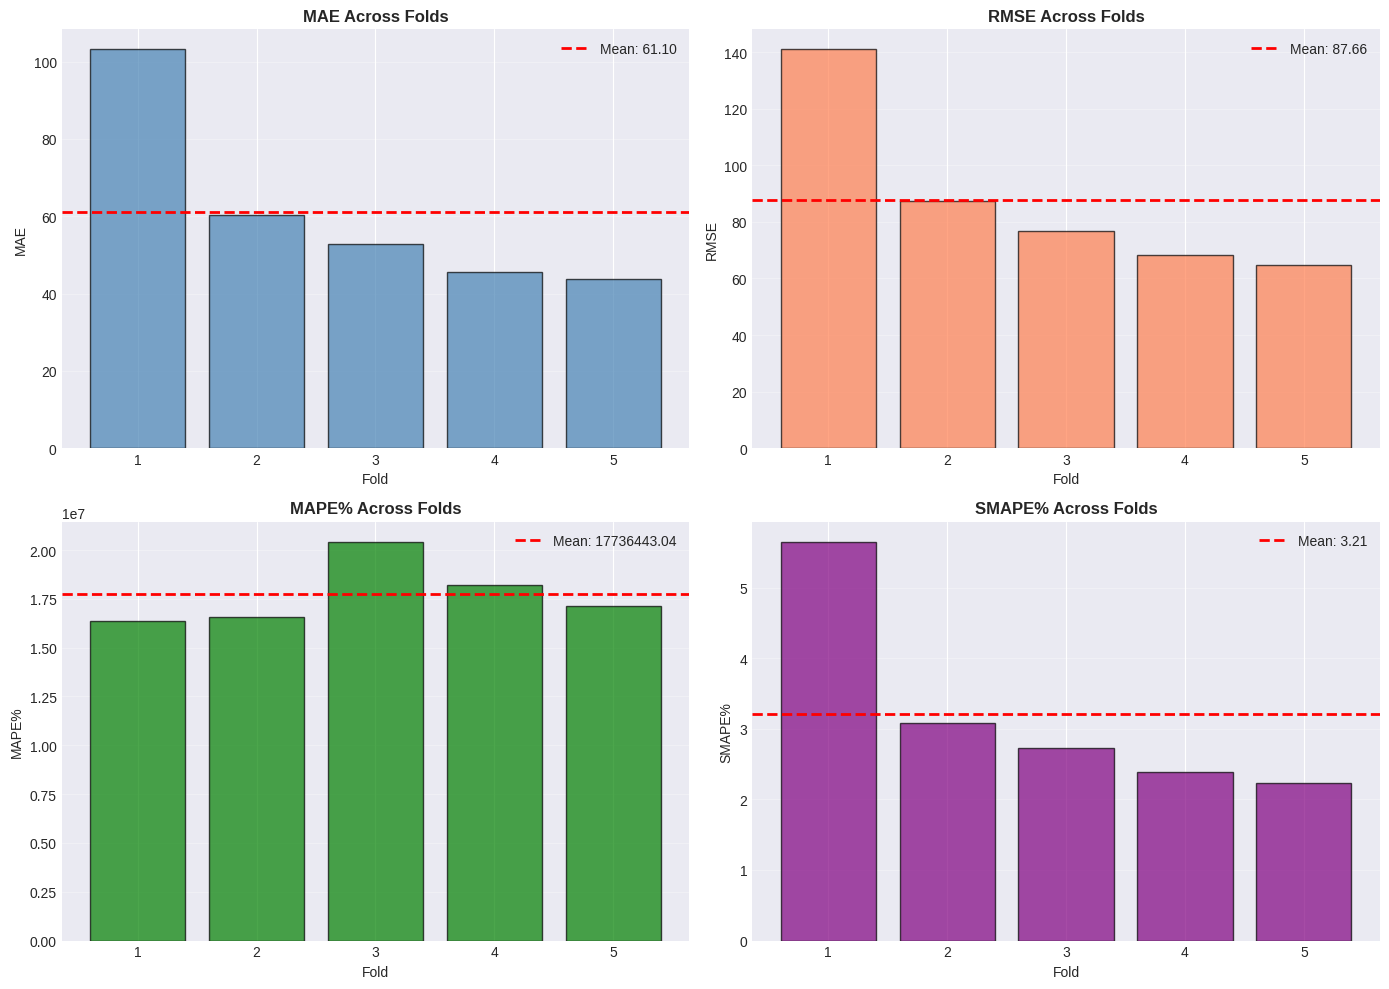

✓ Saved: RSCP_kfold_predictions.png


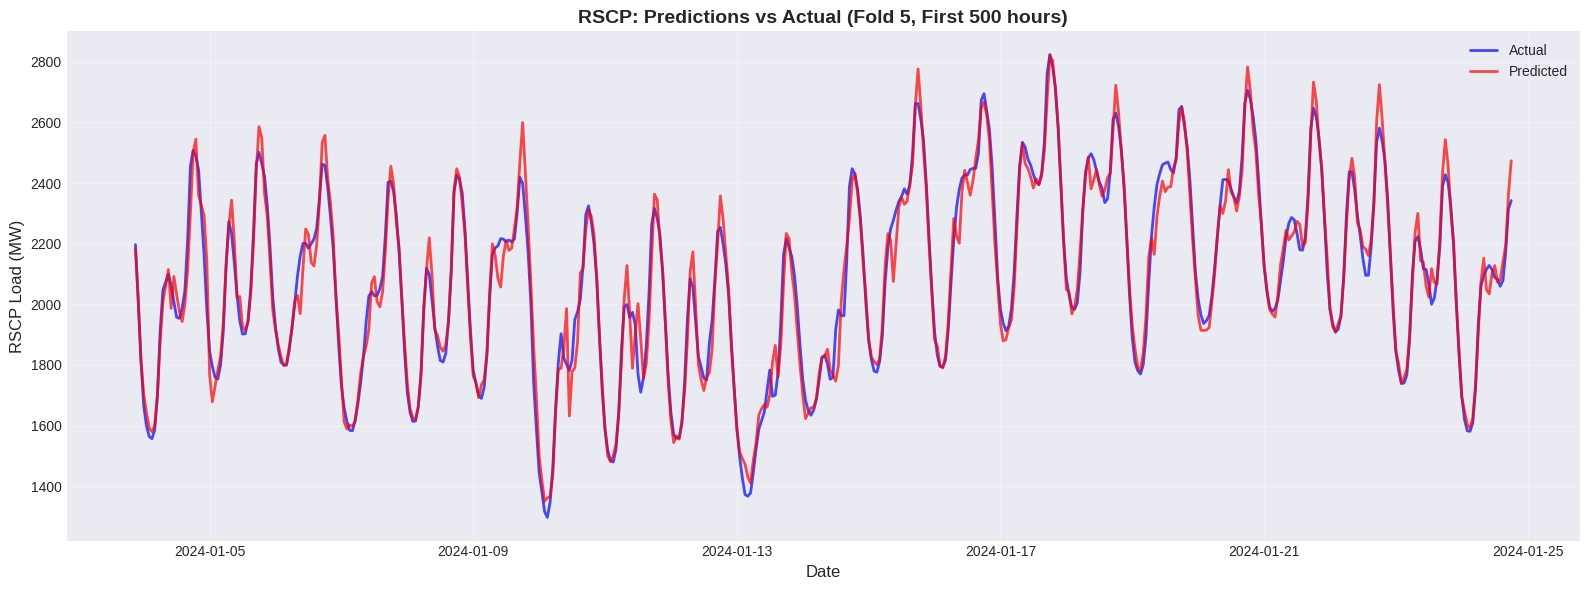

✓ Saved: RSCP_kfold_boxplot.png


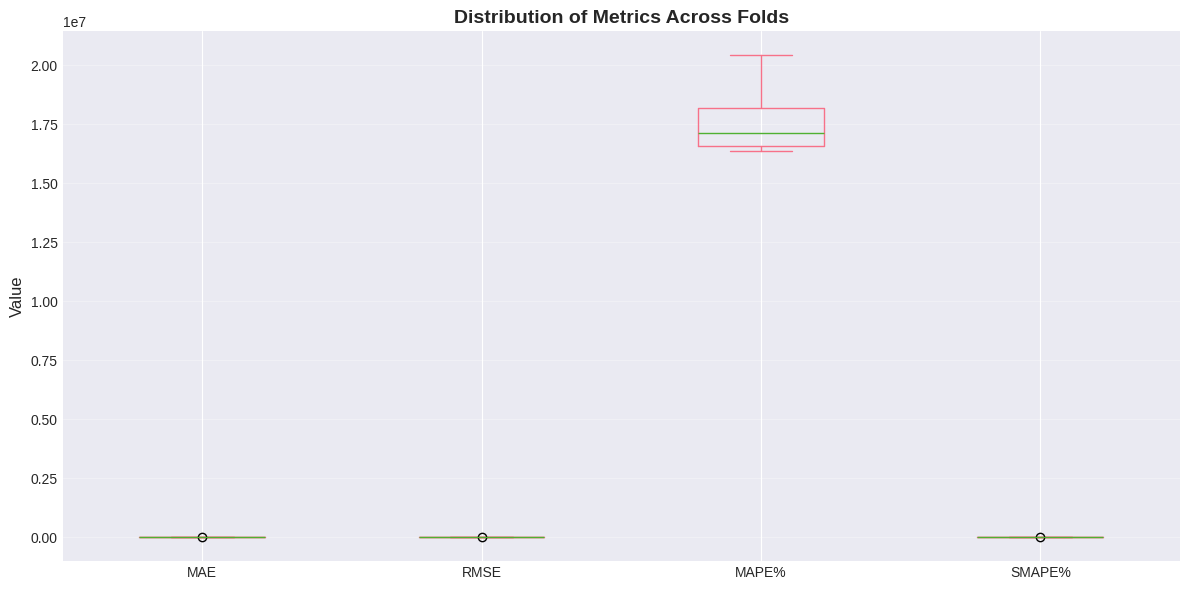

In [ ]:
# ============================================
# VISUALIZATIONS
# ============================================
print("\n📊 Creating visualizations...")

# 1. Metrics across folds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = ['MAE', 'RMSE', 'MAPE%', 'SMAPE%']
colors = ['steelblue', 'coral', 'green', 'purple']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    axes[idx].bar(fold_results_df['fold'], fold_results_df[metric],
                  color=color, alpha=0.7, edgecolor='black')
    axes[idx].axhline(fold_results_df[metric].mean(), color='red',
                     linestyle='--', linewidth=2, label=f'Mean: {fold_results_df[metric].mean():.2f}')
    axes[idx].set_title(f'{metric} Across Folds', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Fold', fontsize=10)
    axes[idx].set_ylabel(metric, fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{TARGET}_kfold_metrics.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved: {TARGET}_kfold_metrics.png")
plt.show()

# 2. Predictions vs Actual (sample from last fold)
fig, ax = plt.subplots(figsize=(16, 6))
last_fold = all_predictions[-1]
plot_len = min(500, len(last_fold))

ax.plot(last_fold['timestamp'][:plot_len], last_fold['true'][:plot_len],
        label='Actual', linewidth=2, alpha=0.7, color='blue')
ax.plot(last_fold['timestamp'][:plot_len], last_fold['pred'][:plot_len],
        label='Predicted', linewidth=2, alpha=0.7, color='red')
ax.set_title(f'{TARGET}: Predictions vs Actual (Fold {K_FOLDS}, First 500 hours)',
            fontweight='bold', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel(f'{TARGET} Load (MW)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{TARGET}_kfold_predictions.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved: {TARGET}_kfold_predictions.png")
plt.show()

# 3. Box plots for metric distributions
fig, ax = plt.subplots(figsize=(12, 6))
fold_results_df[['MAE', 'RMSE', 'MAPE%', 'SMAPE%']].plot(kind='box', ax=ax)
ax.set_title('Distribution of Metrics Across Folds', fontweight='bold', fontsize=14)
ax.set_ylabel('Value', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{TARGET}_kfold_boxplot.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved: {TARGET}_kfold_boxplot.png")
plt.show()


# RNN k-fold

In [ ]:
#!pip install -q tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
import os
warnings.filterwarnings('ignore')

print("="*80)
print("RNN K-FOLD CROSS-VALIDATION FOR LOAD FORECASTING")
print("="*80)
print(f"TensorFlow version: {tf.__version__}")

RNN K-FOLD CROSS-VALIDATION FOR LOAD FORECASTING
TensorFlow version: 2.19.0


In [ ]:
# ============================================
# METRIC FUNCTIONS (MATCHING THE PATTERN)
# ============================================

def smape(true, pred):
    """Symmetric Mean Absolute Percentage Error"""
    denom = (np.abs(true) + np.abs(pred)) / 2.0
    denom = np.where(denom == 0, 1e-6, denom)
    return np.mean(np.abs(true - pred) / denom) * 100.0

def compute_metrics(true, pred):
    """Compute all evaluation metrics"""
    mae = mean_absolute_error(true, pred)
    rmse = float(np.sqrt(((true - pred) ** 2).mean()))
    mape = float(np.mean(np.abs((true - pred) / np.maximum(np.abs(true), 1e-6))) * 100.0)
    smp = float(smape(true, pred))
    r2 = r2_score(true, pred)

    return {
        "MAE": float(mae),
        "RMSE": rmse,
        "MAPE%": mape,
        "SMAPE%": smp,
        "R²": float(r2)
    }


In [ ]:
# ============================================
# DATA PREPARATION
# ============================================
print("\n📊 Loading merged data...")

# Load the merged dataset from EDA
merged_df = pd.read_csv('merged_load_weather_data.csv', parse_dates=['Date'])
print(f"✓ Loaded: {merged_df.shape}")
print(f"Date range: {merged_df['Date'].min()} to {merged_df['Date'].max()}")


📊 Loading merged data...
✓ Loaded: (208920, 29)
Date range: 2001-07-31 23:00:00 to 2025-05-31 22:00:00


In [ ]:
# ============================================
# CONFIGURATION
# ============================================
TARGET = 'CIEP'  # Change to: CIEP, GPI, Res, etc.
K_FOLDS = 5     # Number of folds
N_STEPS = 24    # Sequence length (hours)

print(f"\n🎯 Target: {TARGET}")
print(f"📁 K-Folds: {K_FOLDS}")
print(f"⏰ Sequence length: {N_STEPS} hours")

# Select features
feature_cols = ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed',
                'Pressure', 'Precipitation', 'Hour', 'DayOfWeek',
                'Month', 'Is_Weekend', 'DayOfYear']

# Keep only required columns
required_cols = feature_cols + [TARGET, 'Date']
df = merged_df[required_cols].copy()
df = df.dropna()

print(f"✓ Data after removing NaN: {df.shape}")


🎯 Target: CIEP
📁 K-Folds: 5
⏰ Sequence length: 24 hours
✓ Data after removing NaN: (52400, 13)


In [ ]:
# ============================================
# FEATURE ENGINEERING
# ============================================
print("\n🔧 Creating lag features...")

df['load_lag_1'] = df[TARGET].shift(1)
df['load_lag_2'] = df[TARGET].shift(2)
df['load_lag_24'] = df[TARGET].shift(24)
df['load_lag_168'] = df[TARGET].shift(168)
df['load_rolling_24_mean'] = df[TARGET].rolling(window=24).mean()
df['load_rolling_24_std'] = df[TARGET].rolling(window=24).std()
df['load_rolling_168_mean'] = df[TARGET].rolling(window=168).mean()
df['temp_lag_1'] = df['Temperature'].shift(1)
df['temp_rolling_24_mean'] = df['Temperature'].rolling(window=24).mean()

df = df.dropna()
print(f"✓ Features created: {df.shape}")

# Update feature list
feature_cols = ['Temperature', 'Dew Point', 'Humidity', 'Wind Speed',
                'Pressure', 'Precipitation', 'Hour', 'DayOfWeek',
                'Month', 'Is_Weekend', 'DayOfYear',
                'load_lag_1', 'load_lag_2', 'load_lag_24', 'load_lag_168',
                'load_rolling_24_mean', 'load_rolling_24_std', 'load_rolling_168_mean',
                'temp_lag_1', 'temp_rolling_24_mean']


🔧 Creating lag features...
✓ Features created: (52232, 22)


In [ ]:
# ============================================
# PREPARE DATA FOR K-FOLD
# ============================================
print("\n📦 Preparing data...")

X = df[feature_cols].values
y = df[TARGET].values
dates = df['Date'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


📦 Preparing data...
X shape: (52232, 20)
y shape: (52232,)


In [ ]:
# ============================================
# SEQUENCE CREATION FUNCTION
# ============================================

def create_sequences(X, y, n_steps=24):
    """Create sequences for RNN input"""
    Xs, ys = [], []
    for i in range(len(X) - n_steps):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps])
    return np.array(Xs), np.array(ys)

In [ ]:
# ============================================
# MODEL BUILDER FUNCTION
# ============================================

def build_rnn_model(input_shape):
    """Build SimpleRNN model"""
    model = Sequential([
        SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(32, activation='tanh'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


In [ ]:
# ============================================
# K-FOLD CROSS-VALIDATION
# ============================================
print("\n" + "="*80)
print(f"RUNNING {K_FOLDS}-FOLD TIME SERIES CROSS-VALIDATION")
print("="*80)

# Time Series Split
tscv = TimeSeriesSplit(n_splits=K_FOLDS)

fold_results = []
all_predictions = []
fold_id = 1

for train_idx, test_idx in tscv.split(X):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_id}/{K_FOLDS}")
    print(f"{'='*60}")

    # Split data
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]
    dates_test_fold = dates[test_idx]

    print(f"Train samples: {len(X_train_fold):,}")
    print(f"Test samples: {len(X_test_fold):,}")

    # Scale data
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train_fold)
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1))

    X_test_scaled = scaler_X.transform(X_test_fold)
    y_test_scaled = scaler_y.transform(y_test_fold.reshape(-1, 1))

    # Create sequences
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, N_STEPS)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, N_STEPS)

    print(f"Train sequences: {X_train_seq.shape}")
    print(f"Test sequences: {X_test_seq.shape}")

    # Build model
    input_shape = (N_STEPS, X_train_seq.shape[2])
    model = build_rnn_model(input_shape)

    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)

    # Train
    print("Training...")
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # Predict
    y_pred_scaled = model.predict(X_test_seq, verbose=0)

    # Inverse transform
    y_pred_fold = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_true_fold = scaler_y.inverse_transform(y_test_seq).flatten()

    # Adjust dates for sequences
    dates_test_seq = dates_test_fold[N_STEPS:]

    # Compute metrics
    metrics = compute_metrics(y_true_fold, y_pred_fold)
    metrics["fold"] = fold_id
    metrics["train_size"] = len(X_train_seq)
    metrics["test_size"] = len(X_test_seq)
    fold_results.append(metrics)

    print(f"\n✓ Fold {fold_id} Results:")
    print(f"  MAE:    {metrics['MAE']:.2f} MW")
    print(f"  RMSE:   {metrics['RMSE']:.2f} MW")
    print(f"  MAPE:   {metrics['MAPE%']:.2f}%")
    print(f"  SMAPE:  {metrics['SMAPE%']:.2f}%")
    print(f"  R²:     {metrics['R²']:.4f}")

    # Store predictions for this fold
    fold_predictions = pd.DataFrame({
        'timestamp': dates_test_seq,
        'true': y_true_fold,
        'pred': y_pred_fold,
        'fold': fold_id
    })
    all_predictions.append(fold_predictions)

    fold_id += 1


RUNNING 5-FOLD TIME SERIES CROSS-VALIDATION

FOLD 1/5
Train samples: 8,707
Test samples: 8,705
Train sequences: (8683, 24, 20)
Test sequences: (8681, 24, 20)
Training...

✓ Fold 1 Results:
  MAE:    18.44 MW
  RMSE:   25.62 MW
  MAPE:   4966797.35%
  SMAPE:  3.65%
  R²:     0.8839

FOLD 2/5
Train samples: 17,412
Test samples: 8,705
Train sequences: (17388, 24, 20)
Test sequences: (8681, 24, 20)
Training...

✓ Fold 2 Results:
  MAE:    34.26 MW
  RMSE:   44.83 MW
  MAPE:   5103511.15%
  SMAPE:  6.36%
  R²:     0.7773

FOLD 3/5
Train samples: 26,117
Test samples: 8,705
Train sequences: (26093, 24, 20)
Test sequences: (8681, 24, 20)
Training...

✓ Fold 3 Results:
  MAE:    26.56 MW
  RMSE:   39.13 MW
  MAPE:   5849449.39%
  SMAPE:  4.85%
  R²:     0.8631

FOLD 4/5
Train samples: 34,822
Test samples: 8,705
Train sequences: (34798, 24, 20)
Test sequences: (8681, 24, 20)
Training...

✓ Fold 4 Results:
  MAE:    22.65 MW
  RMSE:   29.89 MW
  MAPE:   4.69%
  SMAPE:  4.62%
  R²:     0.8527

FO

In [ ]:
# ============================================
# AGGREGATE RESULTS
# ============================================
print("\n" + "="*80)
print("K-FOLD CROSS-VALIDATION RESULTS")
print("="*80)

fold_results_df = pd.DataFrame(fold_results)
print("\nPer-Fold Results:")
print(fold_results_df.to_string(index=False))

print("\n" + "="*80)
print("AGGREGATED METRICS (Mean ± Std)")
print("="*80)

metrics_summary = fold_results_df[['MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'R²']].agg(['mean', 'std'])
print(metrics_summary.round(2))


K-FOLD CROSS-VALIDATION RESULTS

Per-Fold Results:
      MAE      RMSE        MAPE%   SMAPE%       R²  fold  train_size  test_size
18.441446 25.618199 4.966797e+06 3.653227 0.883930     1        8683       8681
34.259429 44.827189 5.103511e+06 6.355285 0.777345     2       17388       8681
26.563312 39.131961 5.849449e+06 4.847778 0.863062     3       26093       8681
22.652174 29.887089 4.691131e+00 4.620035 0.852665     4       34798       8681
18.953260 24.671205 3.841445e+00 3.814749 0.884408     5       43503       8681

AGGREGATED METRICS (Mean ± Std)
        MAE   RMSE       MAPE%  SMAPE%    R²
mean  24.17  32.83  3183953.28    4.66  0.85
std    6.52   8.82  2925883.09    1.08  0.04


In [ ]:
# ============================================
# SAVE RESULTS
# ============================================
print("\n💾 Saving results...")

# Create output directory
output_dir = 'rnn_kfold_results'
os.makedirs(output_dir, exist_ok=True)

# Save fold results
fold_results_file = os.path.join(output_dir, f'{TARGET}_kfold_results.csv')
fold_results_df.to_csv(fold_results_file, index=False)
print(f"✓ Saved: {fold_results_file}")

# Save summary
summary_file = os.path.join(output_dir, f'{TARGET}_kfold_summary.csv')
metrics_summary.to_csv(summary_file)
print(f"✓ Saved: {summary_file}")

# Save all predictions (matching the pattern: *_predictions_CRNN.csv)
all_predictions_df = pd.concat(all_predictions, ignore_index=True)
predictions_file = os.path.join(output_dir, f'{TARGET}_predictions_CRNN.csv')
all_predictions_df.to_csv(predictions_file, index=False)
print(f"✓ Saved: {predictions_file}")



💾 Saving results...
✓ Saved: rnn_kfold_results/CIEP_kfold_results.csv
✓ Saved: rnn_kfold_results/CIEP_kfold_summary.csv
✓ Saved: rnn_kfold_results/CIEP_predictions_CRNN.csv



📊 Creating visualizations...
✓ Saved: CIEP_kfold_metrics.png


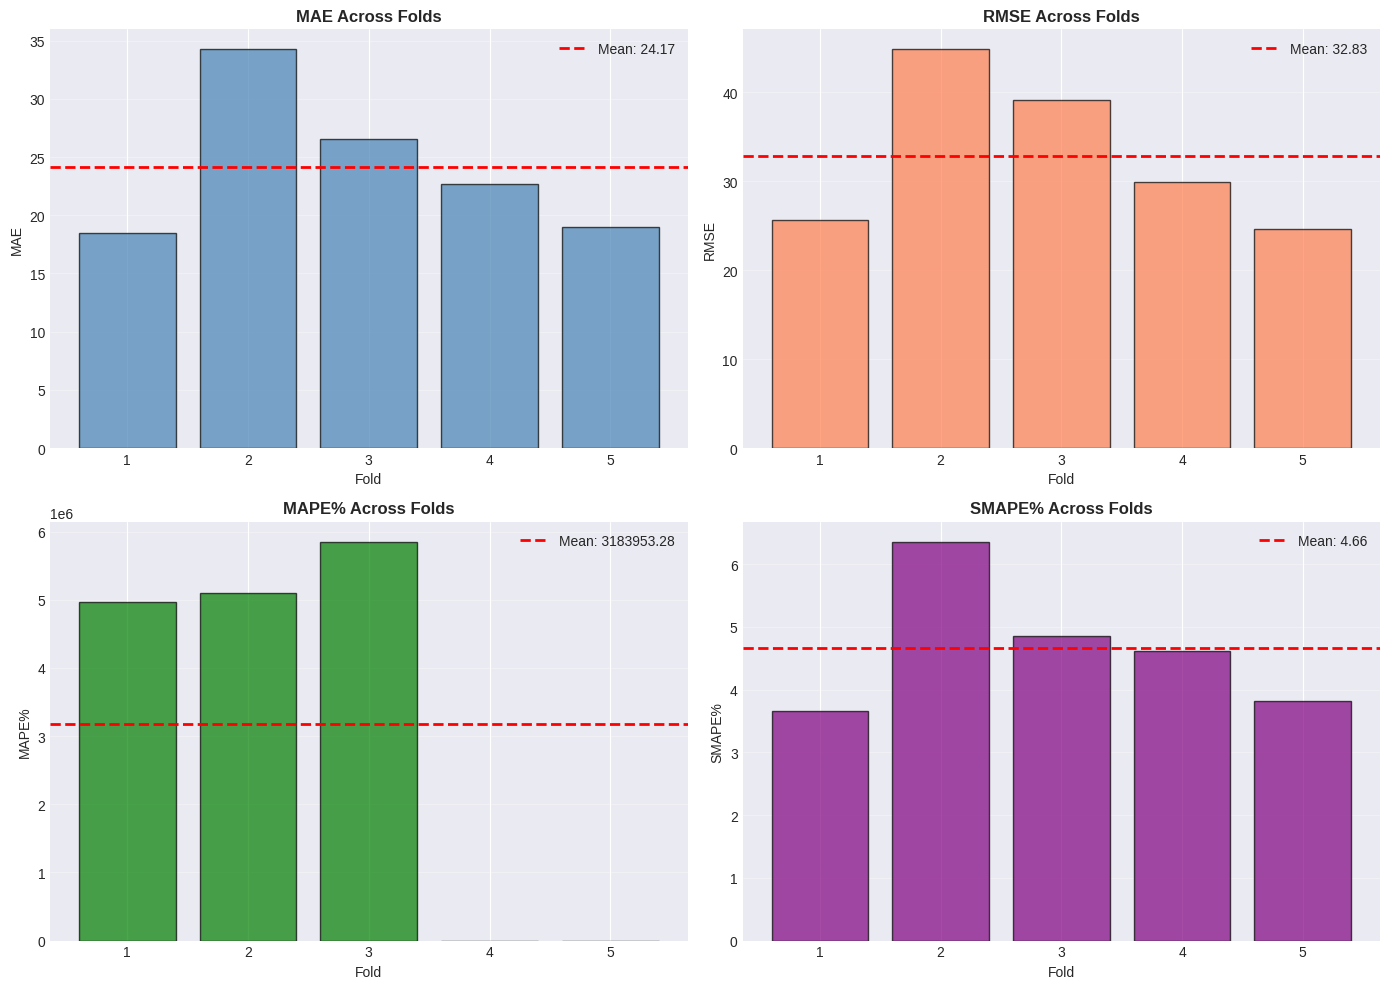

✓ Saved: CIEP_kfold_predictions.png


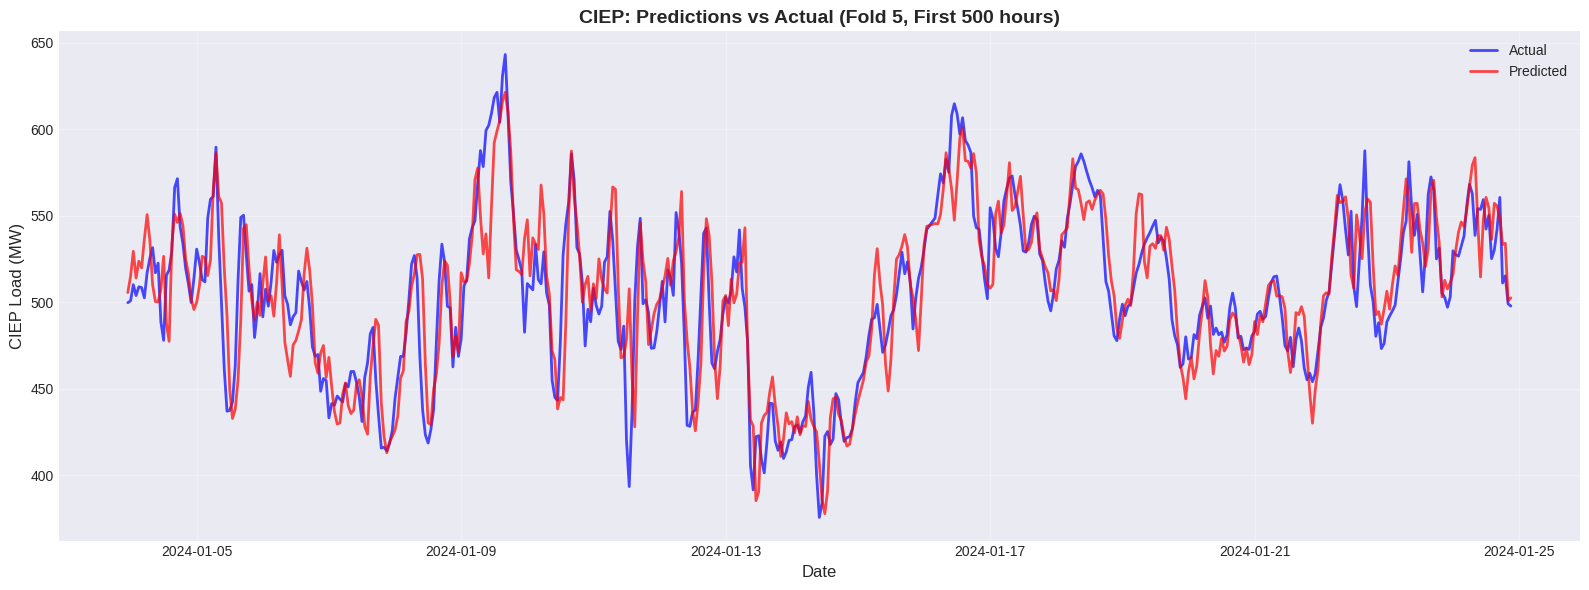

✓ Saved: CIEP_kfold_boxplot.png


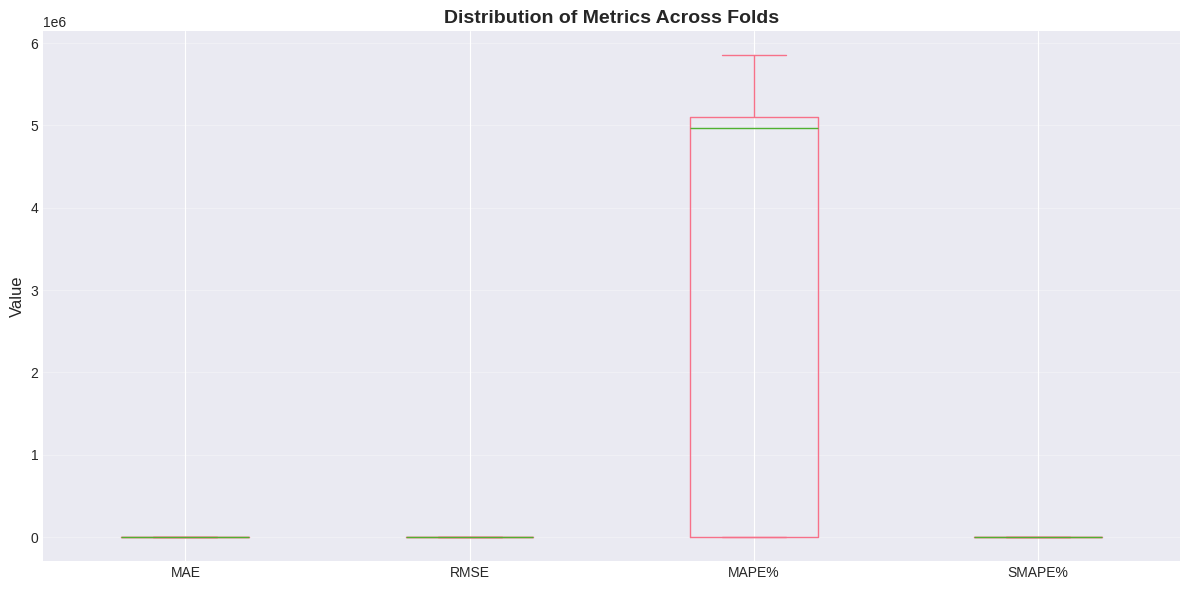

In [ ]:
# ============================================
# VISUALIZATIONS
# ============================================
print("\n📊 Creating visualizations...")

# 1. Metrics across folds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = ['MAE', 'RMSE', 'MAPE%', 'SMAPE%']
colors = ['steelblue', 'coral', 'green', 'purple']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    axes[idx].bar(fold_results_df['fold'], fold_results_df[metric],
                  color=color, alpha=0.7, edgecolor='black')
    axes[idx].axhline(fold_results_df[metric].mean(), color='red',
                     linestyle='--', linewidth=2, label=f'Mean: {fold_results_df[metric].mean():.2f}')
    axes[idx].set_title(f'{metric} Across Folds', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Fold', fontsize=10)
    axes[idx].set_ylabel(metric, fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{TARGET}_kfold_metrics.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved: {TARGET}_kfold_metrics.png")
plt.show()

# 2. Predictions vs Actual (sample from last fold)
fig, ax = plt.subplots(figsize=(16, 6))
last_fold = all_predictions[-1]
plot_len = min(500, len(last_fold))

ax.plot(last_fold['timestamp'][:plot_len], last_fold['true'][:plot_len],
        label='Actual', linewidth=2, alpha=0.7, color='blue')
ax.plot(last_fold['timestamp'][:plot_len], last_fold['pred'][:plot_len],
        label='Predicted', linewidth=2, alpha=0.7, color='red')
ax.set_title(f'{TARGET}: Predictions vs Actual (Fold {K_FOLDS}, First 500 hours)',
            fontweight='bold', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel(f'{TARGET} Load (MW)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{TARGET}_kfold_predictions.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved: {TARGET}_kfold_predictions.png")
plt.show()

# 3. Box plots for metric distributions
fig, ax = plt.subplots(figsize=(12, 6))
fold_results_df[['MAE', 'RMSE', 'MAPE%', 'SMAPE%']].plot(kind='box', ax=ax)
ax.set_title('Distribution of Metrics Across Folds', fontweight='bold', fontsize=14)
ax.set_ylabel('Value', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f'{TARGET}_kfold_boxplot.png'), dpi=300, bbox_inches='tight')
print(f"✓ Saved: {TARGET}_kfold_boxplot.png")
plt.show()


In [ ]:
# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*80)
print("K-FOLD CROSS-VALIDATION COMPLETE!")
print("="*80)

print(f"\n📊 Target: {TARGET}")
print(f"K-Folds: {K_FOLDS}")
print(f"Sequence length: {N_STEPS} hours")
print(f"Features: {len(feature_cols)}")

print(f"\n🏆 Average Performance Across {K_FOLDS} Folds:")
print(f"  MAE:    {fold_results_df['MAE'].mean():.2f} ± {fold_results_df['MAE'].std():.2f} MW")
print(f"  RMSE:   {fold_results_df['RMSE'].mean():.2f} ± {fold_results_df['RMSE'].std():.2f} MW")
print(f"  MAPE:   {fold_results_df['MAPE%'].mean():.2f} ± {fold_results_df['MAPE%'].std():.2f}%")
print(f"  SMAPE:  {fold_results_df['SMAPE%'].mean():.2f} ± {fold_results_df['SMAPE%'].std():.2f}%")
print(f"  R²:     {fold_results_df['R²'].mean():.4f} ± {fold_results_df['R²'].std():.4f}")

print("\n📁 Generated Files:")
print(f"  ✓ {TARGET}_kfold_results.csv")
print(f"  ✓ {TARGET}_kfold_summary.csv")
print(f"  ✓ {TARGET}_predictions_CRNN.csv  (compatible with your validation script!)")
print(f"  ✓ {TARGET}_kfold_metrics.png")
print(f"  ✓ {TARGET}_kfold_predictions.png")
print(f"  ✓ {TARGET}_kfold_boxplot.png")


K-FOLD CROSS-VALIDATION COMPLETE!

📊 Target: GPC
K-Folds: 5
Sequence length: 24 hours
Features: 20

🏆 Average Performance Across 5 Folds:
  MAE:    5.26 ± 4.07 MW
  RMSE:   6.63 ± 4.71 MW
  MAPE:   7.29 ± 7.51%
  SMAPE:  6.58 ± 6.49%
  R²:     0.3935 ± 1.0450

📁 Generated Files:
  ✓ GPC_kfold_results.csv
  ✓ GPC_kfold_summary.csv
  ✓ GPC_predictions_CRNN.csv  (compatible with your validation script!)
  ✓ GPC_kfold_metrics.png
  ✓ GPC_kfold_predictions.png
  ✓ GPC_kfold_boxplot.png


# Not worked out

## CRNN

```
python crnn_jcpl_zip.py --zip_path /file-path/2025-Data.zip --out_dir ./out --seq_len 168 --batch_size 64 --epochs 40

```
CRNN pipeline for JCPL hourly load forecasting that:
- Reads and extracts a ZIP archive with the structure you described (2025-Data.zip).
- Uses cleaned_rate_class_data for per-rate time series.
- Merges Predict With - X/Energy and Predict With - X/Weather (conservative merge_asof).
- Only uses weather rows from 2022 onward for feature merges.
- Trains a Conv1D -> BiLSTM -> Dense model (seq2one).
- Saves per-rate training loss plots and forecast plots.
- Outputs predictions CSVs, model checkpoints, results CSV, and problems CSV.

---

Parameters are as follows:

* Data & I/O

EXTRACT_DIR — temporary extraction dir (/content/jcpl_extracted).

OUT_DIR — where model, CSVs, and PNG plots are saved (/content/output).

* Data split

TRAIN_YEARS = [2022, 2023]

TEST_YEAR = 2024

MIN_TRAIN_HOURS = 24*7 (after feature creation; if missing, file may be skipped)

FALLBACK_TEST_DAYS = 30 (if 2024 missing for a rate, last 30 days used as test)

* Windowing

SEQ_LEN = 168 (7 days)

HORIZON = 1 (one-hour-ahead forecast)

Batching & Workers

BATCH_SIZE = 64

NUM_WORKERS = 2

* Model architecture (Unified CRNN)

EMBED_DIM = 8 (rate-class embedding dimension)

CNN_CHANNELS = 48

CNN_KERNEL = 3

RNN_HIDDEN = 128

RNN_LAYERS = 2

RNN_BIDIR = True

DROPOUT = 0.1

* Training

EPOCHS = 40

LR = 1e-3

WEIGHT_DECAY = 1e-6

EARLY_STOPPING = 8 (stop when no val improvement)

PATIENCE_LR = 5 (LR scheduler patience)

SEED = 42

* Preprocessing / Features

Calendar features created: hour, dayofweek, month, is_weekend.

Lags created: lag_1, lag_24, lag_168.

Rolling features: mean & std with windows 24 and 168.

Weather merge: merges hourly_weather_newark_*.csv (if found) using merge_asof with tolerance 1H. Only weather rows with year >= 2022 are used.

External Energy features: (optional) would follow similar conservative merge (currently only weather auto-merged in the notebook).

Feature scaling: StandardScaler fit over all training (global) features; saved as scaler.pkl.

* Outputs saved

Model checkpoint: unified_crnn_best.pth

training_loss.png

Per-rate: {RATE}_unified_predictions.csv, {RATE}_forecast.png, {RATE}_residuals.png

unified_metrics_summary.csv

scaler.pkl

In [ ]:
!pip install -q torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
!pip install -q openpyxl pyxlsb

In [ ]:
#@title 1. Load

import os, sys, zipfile, shutil, glob, tempfile, math, random, datetime
from pathlib import Path
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
#@title 2. CONFIG: All parameters
# File / IO
#@title 2. CONFIG: All parameters (edit here)

import os
from google.colab import files
import zipfile

# ---- 1. Upload ZIP interactively ----
print("⬆Please upload your 2025-Data.zip file")
uploaded = files.upload()

# Detect uploaded filename
ZIP_PATH = list(uploaded.keys())[0]
print("ZIP uploaded:", ZIP_PATH)

# ---- 2. Create extraction + output folders ----
EXTRACT_DIR = "/content/jcpl_extracted"
OUT_DIR = "/content/output"

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# ---- 3. Extract ZIP ----
print("Extracting ZIP...")
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("✅ Extraction complete. Files extracted to:", EXTRACT_DIR)


# Data split
TRAIN_YEARS = [2022, 2023]
TEST_YEAR  = 2024
MIN_TRAIN_HOURS = 24 * 7   # require at least one week after featurization
FALLBACK_TEST_DAYS = 30    # if 2024 missing, fallback to last 30 days test

# Windowing / dataset
SEQ_LEN = 168       # input sequence length in hours (168 = 7 days)
HORIZON = 1         # forecast horizon (1 = next hour)
BATCH_SIZE = 64

# Model architecture (CRNN with rate embedding)
EMBED_DIM = 8       # embedding dim for rate_class
CNN_CHANNELS = 48   # Conv1D output channels
CNN_KERNEL = 3      # Conv kernel size
RNN_HIDDEN = 128    # LSTM hidden size
RNN_LAYERS = 2      # number of LSTM layers
RNN_BIDIR = True    # use bidirectional LSTM
DROPOUT = 0.1

# Training
EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-6
EARLY_STOPPING = 8
PATIENCE_LR = 5

# Misc
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2
VERBOSE = True

print("DEVICE:", DEVICE)
print("OUT_DIR:", OUT_DIR)

⬆Please upload your 2025-Data.zip file


Saving 2025-Data.zip to 2025-Data.zip
ZIP uploaded: 2025-Data.zip
Extracting ZIP...
✅ Extraction complete. Files extracted to: /content/jcpl_extracted
DEVICE: cuda
OUT_DIR: /content/output


In [ ]:
import os

for root, dirs, files in os.walk("/content/jcpl_extracted", topdown=True):
    print(root)
    for d in dirs:
        print("  📁", d)
    for f in files:
        print("  📄", f)
     # only show the top level


/content/jcpl_extracted
  📁 2025-Data
/content/jcpl_extracted/2025-Data
  📁 Data
/content/jcpl_extracted/2025-Data/Data
  📁 cleaned_rate_class_data
  📁 Predict With - X
  📄 ! Read Me.txt
/content/jcpl_extracted/2025-Data/Data/cleaned_rate_class_data
  📄 Res_cleaned.xlsx
  📄 GSTI_cleaned.xlsx
  📄 GPI_cleaned.xlsx
  📄 CIEP_cleaned.xlsx
  📄 GTC_cleaned.xlsx
  📄 GSTC_cleaned.xlsx
  📄 GPC_cleaned.xlsx
  📄 GTI_cleaned.xlsx
  📄 GSI_cleaned.xlsx
  📄 GSC_cleaned.xlsx
  📄 RSCP_cleaned.xlsx
/content/jcpl_extracted/2025-Data/Data/Predict With - X
  📁 Energy
  📁 Weather
  📁 Economic
  📄 Date_Catagories.xlsx
  📄 ! Read Me.txt
/content/jcpl_extracted/2025-Data/Data/Predict With - X/Energy
  📄 Net_generation_for_utility-scale_photovoltaic_monthly.csv
  📄 Net_generation_for_small-scale_solar_photovoltaic_monthly.csv
  📄 Net_generation_for_wind_monthly.csv
  📄 ! Read Me.txt
  📄 Number_of_customer_accounts_monthly.csv
  📄 Net_generation_for_biomass_monthly.csv
/content/jcpl_extracted/2025-Data/Data/Predi

In [ ]:
#@title 3. Utilities & feature engineering
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def evaluate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(((y_true - y_pred) ** 2).mean())
    denom = np.maximum(np.abs(y_true), 1e-6)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": float(mae), "RMSE": float(rmse), "MAPE%": float(mape)}

def make_features(df):
    """df must contain timestamp (datetime) and load (float). Returns hourly-regularized df with features."""
    df = df.sort_values("timestamp").reset_index(drop=True).copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.set_index("timestamp").asfreq("H")
    df["load"] = df["load"].interpolate(method="time", limit=6).ffill().bfill()
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"] = df.index.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    for lag in [1,24,168]:
        df[f"lag_{lag}"] = df["load"].shift(lag)
    for w in [24,168]:
        df[f"roll_mean_{w}"] = df["load"].shift(1).rolling(window=w, min_periods=1).mean()
        df[f"roll_std_{w}"] = df["load"].shift(1).rolling(window=w, min_periods=1).std().fillna(0)
    df = df.reset_index().dropna().reset_index(drop=True)
    return df

def create_windows(df, feature_cols, seq_len=168, horizon=1):
    vals = df[feature_cols + ["load"]].values
    n = len(df)
    Xs = []; ys = []
    for end_idx in range(seq_len, n - horizon + 1):
        start_idx = end_idx - seq_len
        Xs.append(vals[start_idx:end_idx, :-1])
        ys.append(vals[end_idx + horizon - 1, -1])
    if not Xs:
        return np.empty((0, seq_len, len(feature_cols))), np.empty((0,))
    return np.stack(Xs), np.array(ys)

In [ ]:
#@title 4. Extract ZIP and find cleaned rate-class files
# unzip into EXTRACT_DIR
if os.path.exists(EXTRACT_DIR):
    print("Removing existing extract dir:", EXTRACT_DIR)
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Extracting", ZIP_PATH, "→", EXTRACT_DIR)
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

# try locate cleaned folder
candidates = [
    os.path.join(EXTRACT_DIR, "Data", "cleaned rate class data"),
    os.path.join(EXTRACT_DIR, "Data", "cleaned_rate_class_data"),
    os.path.join(EXTRACT_DIR, "Data", "cleaned rate class data".replace(" ", " ")),
    os.path.join(EXTRACT_DIR, "cleaned_rate_class_data"),
]
cleaned_dir = None
for p in candidates:
    if os.path.exists(p):
        cleaned_dir = p
        break
if cleaned_dir is None:
    matches = glob.glob(os.path.join(EXTRACT_DIR, "**", "*_cleaned.xlsx"), recursive=True)
    if matches:
        cleaned_dir = os.path.dirname(matches[0])
if cleaned_dir is None:
    raise FileNotFoundError("Could not find cleaned rate class data directory in ZIP. Searched under EXTRACT_DIR.")

print("Using cleaned data dir:", cleaned_dir)
files = sorted(glob.glob(os.path.join(cleaned_dir, "*_cleaned.xlsx")) + glob.glob(os.path.join(cleaned_dir, "*.xlsx")))
print("Found files:", [os.path.basename(f) for f in files])

Removing existing extract dir: /content/jcpl_extracted
Extracting 2025-Data.zip → /content/jcpl_extracted
Using cleaned data dir: /content/jcpl_extracted/2025-Data/Data/cleaned_rate_class_data
Found files: ['CIEP_cleaned.xlsx', 'CIEP_cleaned.xlsx', 'GPC_cleaned.xlsx', 'GPC_cleaned.xlsx', 'GPI_cleaned.xlsx', 'GPI_cleaned.xlsx', 'GSC_cleaned.xlsx', 'GSC_cleaned.xlsx', 'GSI_cleaned.xlsx', 'GSI_cleaned.xlsx', 'GSTC_cleaned.xlsx', 'GSTC_cleaned.xlsx', 'GSTI_cleaned.xlsx', 'GSTI_cleaned.xlsx', 'GTC_cleaned.xlsx', 'GTC_cleaned.xlsx', 'GTI_cleaned.xlsx', 'GTI_cleaned.xlsx', 'RSCP_cleaned.xlsx', 'RSCP_cleaned.xlsx', 'Res_cleaned.xlsx', 'Res_cleaned.xlsx']


In [ ]:
#@title 5. Build unified dataset (train: 2022-2023, test: 2024)
all_rows = []
rate_names = []
problems = []
for fp in files:
    try:
        rate_name = os.path.basename(fp).replace("_cleaned.xlsx","").replace(".xlsx","")
        df = pd.read_excel(fp)
        df.columns = [c.lower() for c in df.columns]
        if "timestamp" not in df.columns or "load" not in df.columns:
            # assume first col timestamp, second is load
            df = df.rename(columns={df.columns[0]:"timestamp", df.columns[1]:"load"})
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.sort_values("timestamp").reset_index(drop=True)
        df["rate_class"] = rate_name
        all_rows.append(df[["timestamp","load","rate_class"]])
        rate_names.append(rate_name)
    except Exception as e:
        problems.append({"file":fp, "error":str(e)})
print("Loaded rate classes:", rate_names)
unified = pd.concat(all_rows).reset_index(drop=True)
print("Unified rows:", len(unified))

Loaded rate classes: ['CIEP', 'CIEP', 'GPC', 'GPC', 'GPI', 'GPI', 'GSC', 'GSC', 'GSI', 'GSI', 'GSTC', 'GSTC', 'GSTI', 'GSTI', 'GTC', 'GTC', 'GTI', 'GTI', 'RSCP', 'RSCP', 'Res', 'Res']
Unified rows: 1466832


In [ ]:
#@title 6. Per-rate feature building and stacking (safe fixed version)

def safe_parse_timestamp(col):
    """Robust parsing for weather files like '01-01-2022 01:14'."""
    return pd.to_datetime(col, errors="coerce", infer_datetime_format=True)

feature_dfs = []
scalers = {}

print("\n Checking weather files...")
weather_files = glob.glob(os.path.join(EXTRACT_DIR, "**", "hourly_weather_newark_*.csv"), recursive=True)

if weather_files:
    print(f"  → Found {len(weather_files)} weather files")
    wdfs = []
    for f in weather_files:
        tmp = pd.read_csv(f)

        # find timestamp-like column
        possible_ts = [c for c in tmp.columns if "time" in c.lower() or "date" in c.lower()]
        if not possible_ts:
            print(f"⚠ Skipping weather file (no timestamp column): {f}")
            continue

        tcol = possible_ts[0]
        tmp[tcol] = safe_parse_timestamp(tmp[tcol])
        tmp = tmp.dropna(subset=[tcol])

        wdfs.append(tmp)

    if len(wdfs) == 0:
        weather_df = None
        print("⚠ No valid weather timestamp data found.")
    else:
        weather_df = pd.concat(wdfs, ignore_index=True)

        # filter year >= 2022
        weather_df = weather_df[weather_df[tcol].dt.year >= 2022]

        # floor to hourly
        weather_df["timestamp"] = weather_df[tcol].dt.floor("h")

        # drop duplicates
        weather_df = weather_df.drop_duplicates(subset=["timestamp"])

        # keep only numeric weather columns
        numeric_cols = weather_df.select_dtypes(include=[np.number]).columns.tolist()
        keep_weather_cols = numeric_cols[:4]  # up to 4 numeric features

        if len(keep_weather_cols) == 0:
            print("⚠ No numeric weather features found. Weather merge skipped.")
            weather_df = None
        else:
            weather_df = weather_df[["timestamp"] + keep_weather_cols]
            print(f"  → Weather features used: {keep_weather_cols}")
else:
    weather_df = None
    print("⚠ No weather files found. Skipping weather merge.")


# --------------------------
#  MAIN LOOP
print("\n Building features per rate class...")

feature_dfs = []

for rate in tqdm(sorted(unified["rate_class"].unique()), desc="rates"):
    sub = unified[unified["rate_class"] == rate].copy().reset_index(drop=True)

    # ✔ FIX: Remove duplicate timestamps BEFORE feature creation
    sub["timestamp"] = pd.to_datetime(sub["timestamp"])
    sub = sub.sort_values("timestamp")
    sub = sub.drop_duplicates(subset=["timestamp"], keep="first")

    # build features
    sub_feat = make_features(sub[["timestamp", "load"]])
    sub_feat["rate_class"] = rate

    # optional weather merge
    if weather_df is not None:
        sub_feat = pd.merge_asof(
            sub_feat.sort_values("timestamp"),
            weather_df.sort_values("timestamp"),
            on="timestamp",
            direction="nearest",
            tolerance=pd.Timedelta("1h")
        )

    feature_dfs.append(sub_feat)

# unify
full_df = pd.concat(feature_dfs).reset_index(drop=True)
print("\n Full feature df rows:", len(full_df))
print("Columns:", list(full_df.columns))


 Checking weather files...
  → Found 3 weather files
⚠ No numeric weather features found. Weather merge skipped.

 Building features per rate class...


/tmp/ipython-input-2324078248.py:5: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(col, errors="coerce", infer_datetime_format=True)
/tmp/ipython-input-2324078248.py:5: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(col, errors="coerce", infer_datetime_format=True)
/tmp/ipython-input-2324078248.py:5: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsin


 Full feature df rows: 731568
Columns: ['timestamp', 'load', 'hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_std_24', 'roll_mean_168', 'roll_std_168', 'rate_class']


In [ ]:
#@title 7. Prepare X/y, encode rate_class, select columns
# Only keep rows with years we need for train or test (or will fallback later)
full_df["year"] = full_df["timestamp"].dt.year
train_mask = full_df["year"].isin(TRAIN_YEARS)
test_mask  = full_df["year"] == TEST_YEAR

# If some rate lacks 2024, we'll fallback later when constructing per-rate windows
# For unified model we will only use rate-year combos that have sufficient data after windowing

# label encode rate
le = LabelEncoder()
full_df["rate_id"] = le.fit_transform(full_df["rate_class"])
n_rates = len(le.classes_)
print("Rates:", n_rates)

# feature columns: exclude ['timestamp','load','rate_class','year','rate_id']
exclude = {"timestamp","load","rate_class","year","rate_id"}
feature_cols = [c for c in full_df.columns if c not in exclude]
print("Candidate feature columns:", feature_cols)

# Replace any remaining NaNs with 0 for features
full_df[feature_cols] = full_df[feature_cols].fillna(0)

# We'll standardize numeric features per feature (not per rate) using StandardScaler
scaler = StandardScaler()
full_df[feature_cols] = scaler.fit_transform(full_df[feature_cols].values)

# Save scaler for later
import pickle
with open(os.path.join(OUT_DIR,"scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

Rates: 11
Candidate feature columns: ['hour', 'dayofweek', 'month', 'is_weekend', 'lag_1', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_std_24', 'roll_mean_168', 'roll_std_168']


In [ ]:
#@title 8. Create unified windows (seq_len) for all rates (memory-aware streaming)
# We'll create windows per-rate and stack them, only include windows where the target timestamp is in 2024 (test)
# For training, keep windows whose target timestamp is in 2022-2023

X_list_train=[]; y_list_train=[]; rate_list_train=[]
X_list_test=[];  y_list_test=[];  rate_list_test=[]

for rate in tqdm(sorted(full_df["rate_class"].unique()), desc="build windows per rate"):
    sub = full_df[full_df["rate_class"]==rate].sort_values("timestamp").reset_index(drop=True)
    X, y = create_windows(sub, feature_cols, seq_len=SEQ_LEN, horizon=HORIZON)
    if len(X)==0:
        continue
    # target indices aligned: compute target timestamps
    target_idx_start = SEQ_LEN + HORIZON - 1
    target_timestamps = sub["timestamp"].iloc[target_idx_start: target_idx_start + len(y)].reset_index(drop=True)
    target_years = target_timestamps.dt.year.values
    rate_id = sub["rate_id"].iloc[0]
    # split by year
    train_mask = np.isin(target_years, TRAIN_YEARS)
    test_mask  = (target_years == TEST_YEAR)
    # fallback: if test_mask empty, use last FALLBACK_TEST_DAYS days of series for test
    if not test_mask.any():
        last_idx = len(sub)-1
        # compute how many samples correspond to FALLBACK_TEST_DAYS
        fallback_hours = 24 * FALLBACK_TEST_DAYS
        # find timestamp index where test should start
        test_start_time = sub["timestamp"].iloc[-fallback_hours] if len(sub) > fallback_hours else sub["timestamp"].iloc[-SEQ_LEN]
        test_mask = (target_timestamps >= test_start_time)
        train_mask = ~test_mask
    # append
    if train_mask.any():
        X_list_train.append(X[train_mask])
        y_list_train.append(y[train_mask])
        rate_list_train.append(np.full((X[train_mask].shape[0],), rate_id, dtype=np.int64))
    if test_mask.any():
        X_list_test.append(X[test_mask])
        y_list_test.append(y[test_mask])
        rate_list_test.append(np.full((X[test_mask].shape[0],), rate_id, dtype=np.int64))

# stack
if X_list_train:
    X_train = np.vstack(X_list_train)
    y_train = np.concatenate(y_list_train)
    rate_train = np.concatenate(rate_list_train)
else:
    X_train = np.empty((0,SEQ_LEN,len(feature_cols))); y_train=np.empty((0,)); rate_train=np.empty((0,))

if X_list_test:
    X_test = np.vstack(X_list_test)
    y_test = np.concatenate(y_list_test)
    rate_test = np.concatenate(rate_list_test)
else:
    X_test = np.empty((0,SEQ_LEN,len(feature_cols))); y_test=np.empty((0,)); rate_test=np.empty((0,))

print("Train samples:", X_train.shape[0], "Test samples:", X_test.shape[0])

build windows per rate: 100%|██████████| 11/11 [00:06<00:00,  1.65it/s]


Train samples: 192720 Test samples: 50391


In [ ]:
#@title 9. Dataset, DataLoader, and CRNN model (with rate embedding)
class UnifiedDataset(Dataset):
    def __init__(self, X, y, rate_ids):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.rate_ids = rate_ids.astype(np.int64)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.rate_ids[idx], self.y[idx]

train_ds = UnifiedDataset(X_train, y_train, rate_train)
test_ds = UnifiedDataset(X_test, y_test, rate_test)

from torch.utils.data import random_split
train_size = int(len(train_ds)*0.9)
val_size = len(train_ds) - train_size
if train_size==0:
    raise RuntimeError("Not enough training data after windowing. Try lowering SEQ_LEN or checking data availability.")
train_sub, val_sub = random_split(train_ds, [train_size, val_size])
train_loader = DataLoader(train_sub, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_sub, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

class UnifiedCRNN(nn.Module):
    def __init__(self, input_dim, n_rates, embed_dim, cnn_channels=48, kernel_size=3,
                 rnn_hidden=128, rnn_layers=2, bidir=True, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.embed = nn.Embedding(n_rates, embed_dim)
        # We'll append the embedding to each timestep as additional features
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=input_dim + embed_dim, out_channels=cnn_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.Conv1d(in_channels=cnn_channels, out_channels=cnn_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.rnn = nn.LSTM(input_size=cnn_channels, hidden_size=rnn_hidden,
                           num_layers=rnn_layers, batch_first=True, bidirectional=bidir, dropout=dropout if rnn_layers>1 else 0)
        rnn_out_dim = rnn_hidden * (2 if bidir else 1)
        self.head = nn.Sequential(
            nn.Linear(rnn_out_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    def forward(self, x, rate_ids):
        # x: (batch, seq_len, feat)
        emb = self.embed(rate_ids)                # (batch, embed_dim)
        # expand emb to seq_len and concat to features
        emb_seq = emb.unsqueeze(1).expand(-1, x.size(1), -1)  # (batch, seq_len, embed_dim)
        xcat = torch.cat([x, emb_seq], dim=2)     # (batch, seq_len, feat+embed)
        xperm = xcat.permute(0,2,1)               # (batch, feat+embed, seq_len)
        c = self.conv(xperm)                      # (batch, cnn_ch, seq_len)
        c = c.permute(0,2,1)                      # (batch, seq_len, cnn_ch)
        out, _ = self.rnn(c)                      # (batch, seq_len, rnn_out)
        last = out[:, -1, :]
        return self.head(last).squeeze(1)

model = UnifiedCRNN(input_dim=len(feature_cols),
                    n_rates=n_rates,
                    embed_dim=EMBED_DIM,
                    cnn_channels=CNN_CHANNELS,
                    kernel_size=CNN_KERNEL,
                    rnn_hidden=RNN_HIDDEN,
                    rnn_layers=RNN_LAYERS,
                    bidir=RNN_BIDIR,
                    dropout=DROPOUT).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=PATIENCE_LR)
print(model)

UnifiedCRNN(
  (embed): Embedding(11, 8)
  (conv): Sequential(
    (0): Conv1d(19, 48, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): Dropout(p=0.1, inplace=False)
  )
  (rnn): LSTM(48, 128, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


Starting efficient CRNN training on: cuda


/tmp/ipython-input-1937049656.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler()
/tmp/ipython-input-1937049656.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipython-input-1937049656.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/40  |  train=299412.193011  val=26425.517448
Epoch 2/40  |  train=9771.228341  val=4404.015221
Epoch 3/40  |  train=5460.175743  val=3515.427277
Epoch 4/40  |  train=5063.948675  val=3460.710136
Epoch 5/40  |  train=4227.626258  val=3534.552302
Epoch 6/40  |  train=18245.366004  val=4064.111650
Epoch 7/40  |  train=10176.061333  val=3808.044633
Epoch 8/40  |  train=9407.290403  val=3132.715970
Epoch 9/40  |  train=9057.541386  val=4046.232638
Epoch 10/40  |  train=8436.813903  val=3343.539914
Epoch 11/40  |  train=7972.458163  val=2613.220666
Epoch 12/40  |  train=7512.725369  val=2842.773227
Epoch 13/40  |  train=6954.785124  val=2488.535206
Epoch 14/40  |  train=6594.864910  val=2635.278088
Epoch 15/40  |  train=6232.904074  val=2471.748273
Epoch 16/40  |  train=5861.806666  val=2534.295213
Epoch 17/40  |  train=5514.569648  val=2635.638057
Epoch 18/40  |  train=5276.851445  val=2255.101998
Epoch 19/40  |  train=4733.412556  val=2228.587043
Epoch 20/40  |  train=4095.367183  

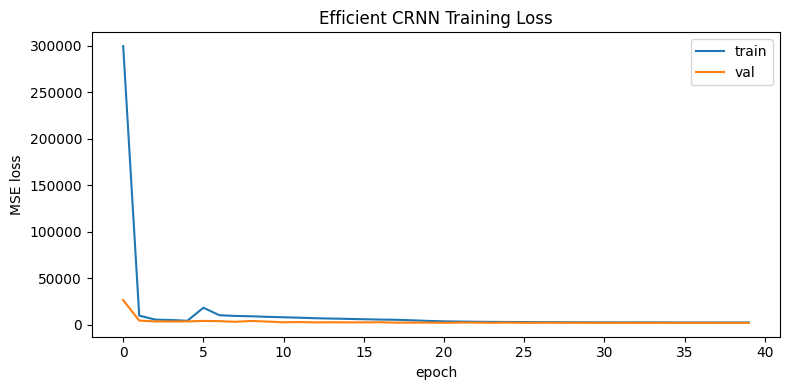

In [ ]:
#@title 10. Efficient Training Loop (fixed: AMP scaler + ReduceLROnPlateau)
import time, math, torch

EPOCHS = 40
BASE_LR = 1e-3
WEIGHT_DECAY = 1e-6
ACCUM_STEPS = 2          # gradient accumulation
WARMUP_EPOCHS = 3
EARLY_STOPPING = 8       # patience

print("Starting efficient CRNN training on:", DEVICE)

best_val = float("inf")
patience = 0
train_losses = []
val_losses = []

# Safe GradScaler creation
if DEVICE.type == "cuda":
    try:
        scaler_amp = torch.amp.GradScaler(device_type="cuda")
    except Exception:
        scaler_amp = torch.cuda.amp.GradScaler()
else:
    scaler_amp = None  # no AMP on CPU

# Cosine LR with warmup
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(1, (EPOCHS - WARMUP_EPOCHS))
    return 0.5 * (1 + math.cos(math.pi * t))

scheduler_epoch = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
# remove verbose argument for compatibility
plateau_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4
)

checkpoint_fp = os.path.join(OUT_DIR, "unified_crnn_best_efficient.pth")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    # TRAINING
    model.train()
    optimizer.zero_grad()
    running = 0.0

    for step, (Xb, rateb, yb) in enumerate(train_loader, start=1):
        Xb = Xb.to(DEVICE); rateb = rateb.to(DEVICE); yb = yb.to(DEVICE)

        if scaler_amp is not None:
            with torch.cuda.amp.autocast():
                preds = model(Xb, rateb)
                loss = criterion(preds, yb) / ACCUM_STEPS
            scaler_amp.scale(loss).backward()
            if step % ACCUM_STEPS == 0 or step == len(train_loader):
                scaler_amp.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler_amp.step(optimizer)
                scaler_amp.update()
                optimizer.zero_grad()
        else:
            # CPU/no-AMP path
            preds = model(Xb, rateb)
            loss = criterion(preds, yb) / ACCUM_STEPS
            loss.backward()
            if step % ACCUM_STEPS == 0 or step == len(train_loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()
                optimizer.zero_grad()

        running += loss.item() * Xb.size(0) * ACCUM_STEPS

    train_loss = running / len(train_loader.dataset)
    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    running_val = 0.0

    with torch.no_grad():
        for Xb, rateb, yb in val_loader:
            Xb = Xb.to(DEVICE); rateb = rateb.to(DEVICE); yb = yb.to(DEVICE)
            if scaler_amp is not None:
                with torch.cuda.amp.autocast():
                    preds = model(Xb, rateb)
                    loss = criterion(preds, yb)
            else:
                preds = model(Xb, rateb)
                loss = criterion(preds, yb)
            running_val += loss.item() * Xb.size(0)

    val_loss = running_val / len(val_loader.dataset)
    val_losses.append(val_loss)

    # LR schedulers
    scheduler_epoch.step()
    plateau_sched.step(val_loss)

    print(f"Epoch {epoch}/{EPOCHS}  |  train={train_loss:.6f}  val={val_loss:.6f}")

    # EARLY STOPPING
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        patience = 0
        torch.save(
            {
                "model_state": model.state_dict(),
                "feature_cols": feature_cols,
                "label_encoder": le,
                "scaler": scaler,
            },
            checkpoint_fp,
        )
    else:
        patience += 1
        if patience >= EARLY_STOPPING:
            print("Early stopping at epoch", epoch)
            break

# LOSS PLOT
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.title("Efficient CRNN Training Loss")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"crnn_training_loss_efficient.png"))

print("Training completed in {:.1f} minutes".format((time.time()-start_time)/60))
print("Best validation loss:", best_val)
print("Checkpoint saved to:", checkpoint_fp)

In [ ]:
# --- Dataset shape sanity check ---
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

try:
    print("X_val shape:", X_val.shape)
    print("y_val shape:", y_val.shape)
except NameError:
    print("Validation data not created yet — run the cell that defines X_val first.")

# check test set if present
try:
    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)
except NameError:
    print("Test data not created yet — skipping.")




X_train shape: (192720, 168, 11)
y_train shape: (192720,)
Validation data not created yet — cell that defines X_val has not been run.


In [ ]:
#@title 11. Evaluate on test set and save per-rate predictions & plots
import torch
from sklearn.preprocessing._label import LabelEncoder
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# allow sklearn LabelEncoder to be unpickled
torch.serialization.add_safe_globals([LabelEncoder])

print("Loading best efficient checkpoint...")

# ckpt_path = os.path.join(OUT_DIR, "unified_crnn_best_efficient.pth")
ckpt_path = "/content/unified_crnn_best_efficient.pth"
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

model.load_state_dict(ckpt["model_state"])

feature_cols = ckpt["feature_cols"]
le = ckpt["label_encoder"]
scaler = ckpt["scaler"]

model.eval()

all_preds = []
all_trues = []
all_rates = []

# RUN MODEL ON TEST SET
with torch.no_grad():
    for Xb, rateb, yb in DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False):
        Xb = Xb.to(DEVICE)
        rateb = rateb.to(DEVICE)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            preds = model(Xb, rateb).cpu().numpy()

        all_preds.append(preds)
        all_trues.append(yb.numpy())
        all_rates.append(rateb.cpu().numpy())

# Concatenate safely
if len(all_preds) > 0:
    all_preds = np.concatenate(all_preds)
    all_trues = np.concatenate(all_trues)
    all_rates = np.concatenate(all_rates)
else:
    all_preds = np.array([])
    all_trues = np.array([])
    all_rates = np.array([])

print("Test samples:", len(all_trues))

# OVERALL METRICS
if len(all_trues) > 0:
    metrics = evaluate_metrics(all_trues, all_preds)
    print("Overall test metrics:", metrics)
else:
    print("WARNING: No test samples. Metrics skipped.")
    metrics = {"MAE": None, "RMSE": None, "MAPE%": None}

# REGENERATE WINDOWS TO RECOVER TIMESTAMPS (per rate)
print("Rebuilding timestamps for per-rate outputs...")

out_rows = []
idx = 0

for rate in sorted(full_df["rate_class"].unique()):
    sub = full_df[full_df["rate_class"] == rate].sort_values("timestamp").reset_index(drop=True)

    # rebuild windows for this rate
    Xr, yr = create_windows(sub, feature_cols, seq_len=SEQ_LEN, horizon=HORIZON)

    if len(Xr) == 0:
        continue

    # timestamp of target for each window
    target_idx_start = SEQ_LEN + HORIZON - 1
    target_ts = sub["timestamp"].iloc[target_idx_start: target_idx_start + len(yr)].reset_index(drop=True)

    # reconstruct test mask used earlier
    target_years = target_ts.dt.year.values
    test_mask_local = (target_years == TEST_YEAR)

    if not test_mask_local.any():
        # fallback: last X hours
        fallback_hours = 24 * FALLBACK_TEST_DAYS
        cutoff = sub["timestamp"].iloc[-fallback_hours] if len(sub) > fallback_hours else sub["timestamp"].iloc[-SEQ_LEN]
        test_mask_local = (target_ts >= cutoff)

    n_this_rate = test_mask_local.sum()
    if n_this_rate == 0:
        continue

    # slice predictions for this rate
    preds_slice = all_preds[idx : idx + n_this_rate]
    trues_slice = all_trues[idx : idx + n_this_rate]
    ts_slice = target_ts[test_mask_local].reset_index(drop=True)

    # advance global index
    idx += n_this_rate

    # recover readable rate label
    rate_id_numeric = int(full_df[full_df["rate_class"] == rate]["rate_id"].iloc[0])
    rate_label = le.inverse_transform([rate_id_numeric])[0]

    # SAVE RESULT CSV
    df_out = pd.DataFrame({
        "timestamp": ts_slice,
        "true": trues_slice,
        "pred": preds_slice
    })

    csv_fp = os.path.join(OUT_DIR, f"{rate_label}_predictions_CRNN.csv")
    df_out.to_csv(csv_fp, index=False)

    # PLOT FORECAST vs TRUE
    plt.figure(figsize=(12,3))
    plt.plot(df_out["timestamp"], df_out["true"], label="true", lw=1)
    plt.plot(df_out["timestamp"], df_out["pred"], label="pred", lw=1)
    plt.title(f"{rate_label} — Unified CRNN Forecast (Test)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{rate_label}_forecast_CRNN.png"))
    plt.close()

    # RESIDUAL PLOT
    resid = df_out["true"] - df_out["pred"]
    plt.figure(figsize=(10,2))
    plt.plot(df_out["timestamp"], resid, lw=1)
    plt.title(f"{rate_label} residuals")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{rate_label}_residuals_CRNN.png"))
    plt.close()

# SAVE SUMMARY
summary = {
    "MAE": metrics["MAE"],
    "RMSE": metrics["RMSE"],
    "MAPE%": metrics["MAPE%"],
    "n_test_samples": len(all_trues)
}

pd.DataFrame([summary]).to_csv(os.path.join(OUT_DIR, "crnn_unified_metrics_summary.csv"), index=False)

print("Saved per-rate CSVs and plots →", OUT_DIR)

In [ ]:
#@title 12. List outputs
print("Output files:")
for f in sorted(glob.glob(os.path.join(OUT_DIR,"*"))):
    print("-", os.path.basename(f))